# Full workflow: external gate plane + band structure + field sweep
This notebook uses the `semiconductor` helpers to apply an external charged plane potential in GPAW, visualize it, compute a band structure along a k-path, and sweep field strengths while saving results after each step for safe interruption/restart.


In [1]:
# Imports
import os
import sys
import csv
from datetime import datetime

import numpy as np
#import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from common.mpl_style import set_mpl_style
set_mpl_style()
from gpaw import restart

# When running a notebook from inside this folder, import local modules directly
sys.path.insert(0, os.path.abspath('.'))

from external_potentials import ChargedPlanePotential, register_with_gpaw
from gpaw_hooks import apply_external
from analysis import compute_gap, sweep_field_gaps, band_structure_with_path
from viz import plot_potential_slice, compute_external_grid

# Ensure our custom external potential can be deserialized by GPAW restarts
register_with_gpaw()


In [2]:
# Paths and output setup
gpw_path = '../gpw/ab.gpw'  # adjust if needed
out_dir = '../gpw'  # reuse gpw directory for outputs
os.makedirs(out_dir, exist_ok=True)

# Result files for safe interruption
sweep_csv = os.path.join(out_dir, 'field_sweep_results.csv')
log_txt = os.path.join(out_dir, 'field_sweep.log')

def log(msg):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{timestamp}] {msg}'
    print(line)
    with open(log_txt, 'a', encoding='utf-8') as f:
        f.write(line + '\n')


In [3]:
# Load atoms and base calculator
atoms, calc0 = restart(gpw_path)

# Determine z-plane (e.g., 3 Å above the top layer)
z_atoms = atoms.positions[:, 2]
z_plane = float(z_atoms.max() + 3.0)
z_plane


6.35

## Visualize external potential


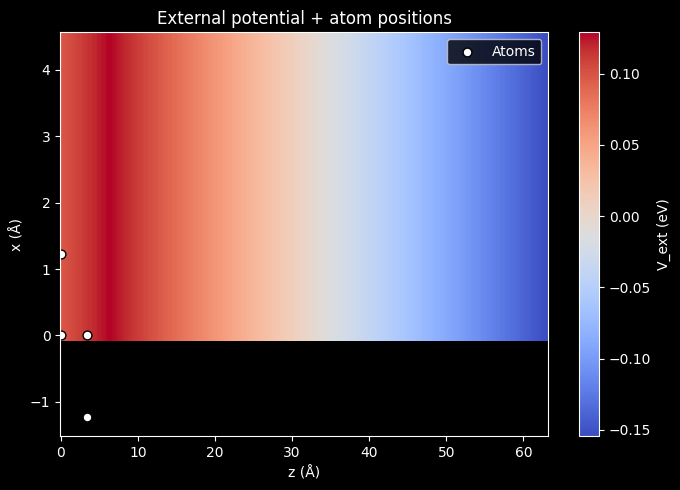

In [22]:
# Choose a small example field strength (A ≈ Ez in eV/Å)
A = 0.005
ext = ChargedPlanePotential(A=A, z_plane=z_plane)

# Visualize the external potential on the GPAW grid
Vext, (x, y, z) = compute_external_grid(calc0, ext)
plot_potential_slice(Vext, (x, y, z), atoms)
plt.show()


## Apply potential and run SCF (regular)


In [23]:
calc = apply_external(calc0, atoms, ext, txt=os.path.join(out_dir, f'ab_gate_plane_A{A:.3f}.txt'))
atoms.calc = calc
_ = atoms.get_potential_energy()  # triggers a regular SCF with the external potential
gpw_out = os.path.join(out_dir, f'ab_gate_plane_A{A:.3f}.gpw')
calc.write(gpw_out)
gpw_out


KeyboardInterrupt: 

## Band structure along a k-path


In [ ]:
bs = band_structure_with_path(calc, path='GKMG', npoints=30, nbands=16, convergence_bands=8)
energies = bs.energies[0]
EF = calc.get_fermi_level()
E_shift = energies - EF

plt.figure(figsize=(6, 4))
for n in range(E_shift.shape[1]):
    plt.plot(E_shift[:, n])
plt.ylim(-1, 1)
plt.xlabel('k-path index')
plt.ylabel('Energy (eV)')
plt.title('Bilayer with gate potential')
plt.tight_layout()
plt.show()


# High-resolution K-zoom bands (BandPath-based zooming) — compute from CSV list and SAVE to disk


from gpaw import GPAW  # noqa: F401 (ensures restart works for all gpw variants)
from ase.dft.kpoints import get_bandpath, kpoint_convert
import numpy as _np
import numpy as np
import csv as _csv

# Zoom settings inspired by save_pi_dft_bands (no pi-band filtering here)
_zoom_path_labels = ['G', 'M', 'K', 'G']
_zoom_npoints_pool = 60           # pool of points before zooming (per full path)
_zoom_label = 'K'                 # special point to zoom around
_zoom_distance = 0.10             # diameter (1/Å) in Cartesian k-space for filtering
_nbands = 16
_conv = {'bands': 8}
_overwrite_zoom = True

# Build list of (Ez, gpw_path) strictly from CSV for resume-correctness
fields_from_csv = []
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as _f:
        _reader = _csv.DictReader(_f)
        for _row in _reader:
            try:
                _Ez = float(_row['Ez'])
            except Exception:
                continue
            _gpw = _row.get('gpw_path') or os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
            fields_from_csv.append((_Ez, _gpw))
else:
    # fallback: use current fields list if CSV missing
    for _Ez in fields:
        _Ez = float(_Ez)
        _gpw = os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
        fields_from_csv.append((_Ez, _gpw))

for Ez, gpw_Ez in np.array(fields_from_csv):
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz')

    if not os.path.exists(gpw_Ez):
        log(f"GPW not found for Ez={Ez:.3f}: {gpw_Ez} — skipping K-zoom compute")
        continue

    if os.path.exists(npz_Ez) and not _overwrite_zoom:
        log(f"K-zoom NPZ already exists for Ez={Ez:.3f}: {npz_Ez} — skipping")
        continue

    # Ensure custom potential is registered before restart
    register_with_gpaw()

    # Restart calculator for this field
    atomsK, calcK = restart(gpw_Ez)

    # 1) Build the bandpath and k-point pool
    bp = get_bandpath(_zoom_path_labels, atomsK.cell, npoints=_zoom_npoints_pool)
    kpts = bp.kpts  # reduced coordinates (skpts)
    # Cartesian k-points (1/Å) for distance-based filtering
    kpts_cart = kpoint_convert(atomsK.cell, skpts_kc=kpts)

    # 2) Zoom: filter points within zoom_distance/2 of the special point (Cartesian)
    if _zoom_label not in _zoom_path_labels:
        log(f"Zoom label '{_zoom_label}' not in path {_zoom_path_labels} — skipping Ez={Ez:.3f}")
        continue

    k_special = kpoint_convert(atomsK.cell, skpts_kc=bp.special_points[_zoom_label])
    dist = np.linalg.norm(kpts_cart - k_special, axis=1)
    mask = dist < (_zoom_distance / 2.0)

    if not np.any(mask):
        log(f"No k-points within zoom window for Ez={Ez:.3f} (distance={_zoom_distance}). Consider increasing zoom_distance.")
        continue

    kpts_zoom = kpts[mask]
    kpts_cart_zoom = kpts_cart[mask]

    # 3) Build cumulative x-axis along the filtered path (Cartesian distance)
    if len(kpts_cart_zoom) >= 2:
        diffs = np.diff(kpts_cart_zoom, axis=0)
        seg = np.linalg.norm(diffs, axis=1)
        x = np.concatenate([[0.0], np.cumsum(seg)])
    else:
        x = np.array([0.0])

    # 4) Compute bands with explicit k-points (fixed_density)
    bs_calc = calcK.fixed_density(
        nbands=_nbands,
        symmetry='off',
        kpts=kpts_zoom,  # explicit reduced k-points
        convergence=_conv,
    )
    bs = bs_calc.band_structure()

    E = bs.energies[0]
    EF = float(bs_calc.get_fermi_level())
    E_shift = E - EF

    # 5) Save zoomed dataset
    try:
        os.makedirs(os.path.dirname(npz_Ez), exist_ok=True)
        np.savez_compressed(
            npz_Ez,
            x=np.asarray(x),
            kpts=np.asarray(kpts_zoom),
            kpts_cart=np.asarray(kpts_cart_zoom),
            E=np.asarray(E_shift),
            EF=float(EF),
            Ez=float(Ez),
            nbands=int(_nbands),
            conv_bands=int(_conv['bands']),
            path=np.array(_zoom_path_labels, dtype=object),
            npoints_pool=int(_zoom_npoints_pool),
            zoom_label=str(_zoom_label),
            zoom_distance=float(_zoom_distance),
        )
        log(f"Saved K-zoom bands for Ez={Ez:.3f} to {npz_Ez}")
    except Exception as _e:
        log(f"Error saving K-zoom bands for Ez={Ez:.3f}: {_e}")

# Done saving K-zoom band data for all available fields.


## Field sweep with interruption-safe saving
- Results are appended to a CSV after each field.
- If the CSV already contains an entry for a field value, it will be skipped (resume capability).


In [156]:
#fields = np.concatenate([np.linspace(0.01, 0.02, 11), np.linspace(0.02, 0.5, 21)])
fields = np.concatenate([np.linspace(0, 0.02, 21), np.linspace(0.02, 0.2, 19), np.linspace(0.2, 1.0, 9)])

In [158]:
fields

array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
       0.018, 0.019, 0.02 , 0.02 , 0.03 , 0.04 , 0.05 , 0.06 , 0.07 ,
       0.08 , 0.09 , 0.1  , 0.11 , 0.12 , 0.13 , 0.14 , 0.15 , 0.16 ,
       0.17 , 0.18 , 0.19 , 0.2  , 0.2  , 0.3  , 0.4  , 0.5  , 0.6  ,
       0.7  , 0.8  , 0.9  , 1.   ])

In [159]:
# Define field values (eV/Å)
from ase.dft.bandgap import  bandgap
# Load existing results (if any) to enable resume
existing = {}
if os.path.exists(sweep_csv):
    print(f'Reading csv')
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            existing[np.round(float(row['Ez']), 3)] = float(row['gap'])
else:
    print(f'no file {sweep_csv} found')

# Prepare CSV with header if new
new_file = not os.path.exists(sweep_csv)
if new_file:
    with open(sweep_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['Ez', 'gap', 'gpw_path'])

results = []
for Ez in fields:
    Ez = float(Ez)
    Ez = np.round(Ez, 3)
    if Ez in existing:
        log(f'Skipping Ez={Ez:.3f} eV/Å (already in results)')
        results.append((Ez, existing[Ez]))
        continue

    log(f'Running Ez={Ez:.3f} eV/Å')
    ext = ChargedPlanePotential(A=Ez, z_plane=z_plane)
    calcE = apply_external(calc0, atoms, ext, txt=os.path.join(out_dir, f'gate_A{Ez:.3f}.txt'))

    # Trigger a regular SCF with the external potential
    _ = atoms.get_potential_energy()

    # Save calculator state for this field
    gpw_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}.gpw')
    calcE.write(gpw_Ez)

    # Band structure and gap
    bsE = band_structure_with_path(calcE, path='GKMG', npoints=30, nbands=16, convergence_bands=8)
    energies = bsE.energies[0]
    EF = calcE.get_fermi_level()
    E = energies - EF
    #gap = bandgap(calcE) #float(compute_gap(E))
    #gap=0
    gap =0
    results.append((Ez, gap))

    # Append to CSV immediately (interruption-safe)
    with open(sweep_csv, 'a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([f'{Ez:.6f}', f'{gap:.6f}', gpw_Ez])
    log(f'Saved Ez={Ez:.3f}, gap={gap:.4f} eV to CSV and {gpw_Ez}')

# Show summary
for Ez, gap in results:
    print(f'Ez={Ez:.3f} eV/Å -> gap={gap:.4f} eV')


Reading csv
[2025-12-17 01:43:53] Skipping Ez=0.000 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.001 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.002 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.003 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.004 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.005 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.006 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.007 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.008 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.009 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.010 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.011 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.012 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.013 eV/Å (already in results)
[2025-12-17 01:43:53] Skipping Ez=0.014 eV/Å (already in results

KeyboardInterrupt: 

In [105]:
tatoms, tcalc = restart('../gpw/ab_gate_plane_A0.000.gpw')

In [108]:
gap, vbm, cbm = bandgap(tcalc)

In [110]:
gap

np.float64(0.6141088108461938)

# High-resolution K-zoom bands (BandPath-based zooming) — compute from CSV list and SAVE to disk


In [21]:
from gpaw import GPAW  # noqa: F401 (ensures restart works for all gpw variants)
from ase.dft.kpoints import get_bandpath, kpoint_convert
import numpy as _np
import numpy as np
import csv as _csv

# Zoom settings inspired by save_pi_dft_bands (no pi-band filtering here)
_zoom_path_labels = ['G', 'M', 'K', 'G']
_zoom_npoints_pool = 200          # pool of points before zooming (per full path)
_zoom_label = 'K'                # special point to zoom around
_zoom_distance = 0.5            # diameter (1/Å) in Cartesian k-space for filtering
_nbands = 16
_conv = {'bands': 8}
_overwrite_zoom = False

# Build list of (Ez, gpw_path) strictly from CSV for resume-correctness
fields_from_csv = []
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as _f:
        _reader = _csv.DictReader(_f)
        for _row in _reader:
            try:
                _Ez = float(_row['Ez'])
            except Exception:
                continue
            _gpw = _row.get('gpw_path') or os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
            fields_from_csv.append((_Ez, _gpw))
else:
    # fallback: use current fields list if CSV missing
    for _Ez in fields:
        _Ez = float(_Ez)
        _gpw = os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
        fields_from_csv.append((_Ez, _gpw))

for Ez, gpw_Ez in np.array(fields_from_csv):
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz')

    if not os.path.exists(gpw_Ez):
        log(f"GPW not found for Ez={Ez:.3f}: {gpw_Ez} — skipping K-zoom compute")
        continue

    if os.path.exists(npz_Ez) and not _overwrite_zoom:
        log(f"K-zoom NPZ already exists for Ez={Ez:.3f}: {npz_Ez} — skipping")
        continue

    # Ensure custom potential is registered before restart
    register_with_gpaw()

    # Restart calculator for this field
    atomsK, calcK = restart(gpw_Ez)

    # 1) Build the bandpath and k-point pool
    bp = get_bandpath(_zoom_path_labels, atomsK.cell, npoints=_zoom_npoints_pool)
    kpts = bp.kpts  # reduced coordinates (skpts)
    # Cartesian k-points (1/Å) for distance-based filtering
    kpts_cart = kpoint_convert(atomsK.cell, skpts_kc=kpts)

    # 2) Zoom: filter points within zoom_distance/2 of the special point (Cartesian)
    if _zoom_label not in _zoom_path_labels:
        log(f"Zoom label '{_zoom_label}' not in path {_zoom_path_labels} — skipping Ez={Ez:.3f}")
        continue

    k_special = kpoint_convert(atomsK.cell, skpts_kc=bp.special_points[_zoom_label])
    dist = np.linalg.norm(kpts_cart - k_special, axis=1)
    mask = dist < (_zoom_distance / 2.0)

    if not np.any(mask):
        log(f"No k-points within zoom window for Ez={Ez:.3f} (distance={_zoom_distance}). Consider increasing zoom_distance.")
        continue

    kpts_zoom = kpts[mask]
    kpts_cart_zoom = kpts_cart[mask]

    # 3) Build cumulative x-axis along the filtered path (Cartesian distance)
    if len(kpts_cart_zoom) >= 2:
        diffs = np.diff(kpts_cart_zoom, axis=0)
        seg = np.linalg.norm(diffs, axis=1)
        x = np.concatenate([[0.0], np.cumsum(seg)])
    else:
        x = np.array([0.0])

    # 4) Compute bands with explicit k-points (fixed_density)
    bs_calc = calcK.fixed_density(
        nbands=_nbands,
        symmetry='off',
        kpts=kpts_zoom,  # explicit reduced k-points
        convergence=_conv,
    )
    bs = bs_calc.band_structure()

    E = bs.energies[0]
    EF = float(bs_calc.get_fermi_level())
    E_shift = E - EF

    # 5) Save zoomed dataset
    try:
        os.makedirs(os.path.dirname(npz_Ez), exist_ok=True)
        np.savez_compressed(
            npz_Ez,
            x=np.asarray(x),
            kpts=np.asarray(kpts_zoom),
            kpts_cart=np.asarray(kpts_cart_zoom),
            E=np.asarray(E_shift),
            EF=float(EF),
            Ez=float(Ez),
            nbands=int(_nbands),
            conv_bands=int(_conv['bands']),
            path=np.array(_zoom_path_labels, dtype=object),
            npoints_pool=int(_zoom_npoints_pool),
            zoom_label=str(_zoom_label),
            zoom_distance=float(_zoom_distance),
        )
        log(f"Saved K-zoom bands for Ez={Ez:.3f} to {npz_Ez}")
    except Exception as _e:
        log(f"Error saving K-zoom bands for Ez={Ez:.3f}: {_e}")

# Done saving K-zoom band data for all available fields.


[2026-01-03 12:48:33] K-zoom NPZ already exists for Ez=0.000: ../gpw/ab_gate_plane_A0.000_bands_KZOOM.npz — skipping
[2026-01-03 12:48:33] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2026-01-03 12:48:33] K-zoom NPZ already exists for Ez=0.002: ../gpw/ab_gate_plane_A0.002_bands_KZOOM.npz — skipping
[2026-01-03 12:48:33] K-zoom NPZ already exists for Ez=0.003: ../gpw/ab_gate_plane_A0.003_bands_KZOOM.npz — skipping
[2026-01-03 12:48:33] K-zoom NPZ already exists for Ez=0.004: ../gpw/ab_gate_plane_A0.004_bands_KZOOM.npz — skipping
[2026-01-03 12:48:33] K-zoom NPZ already exists for Ez=0.005: ../gpw/ab_gate_plane_A0.005_bands_KZOOM.npz — skipping
[2026-01-03 12:48:33] K-zoom NPZ already exists for Ez=0.006: ../gpw/ab_gate_plane_A0.006_bands_KZOOM.npz — skipping
[2026-01-03 12:48:33] K-zoom NPZ already exists for Ez=0.007: ../gpw/ab_gate_plane_A0.007_bands_KZOOM.npz — skipping
[2026-01-03 12:48:33] K-zoom NPZ already exists for Ez=0.008: ..

In [143]:

fields_from_csv

array([[0.0, '../gpw/ab_gate_plane_A0.000.gpw'],
       [0.001, '../gpw/ab_gate_plane_A0.001.gpw'],
       [0.002, '../gpw/ab_gate_plane_A0.002.gpw'],
       [0.003, '../gpw/ab_gate_plane_A0.003.gpw'],
       [0.004, '../gpw/ab_gate_plane_A0.004.gpw'],
       [0.005, '../gpw/ab_gate_plane_A0.005.gpw'],
       [0.006, '../gpw/ab_gate_plane_A0.006.gpw']], dtype=object)

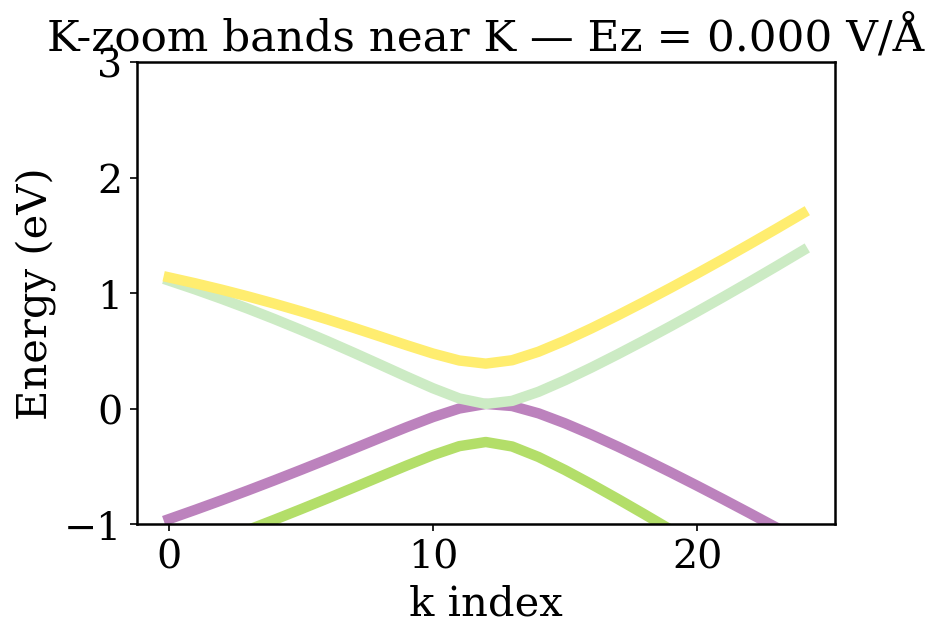

[2026-01-03 12:49:14] Ez=0.000 -> gap=0.000036 eV


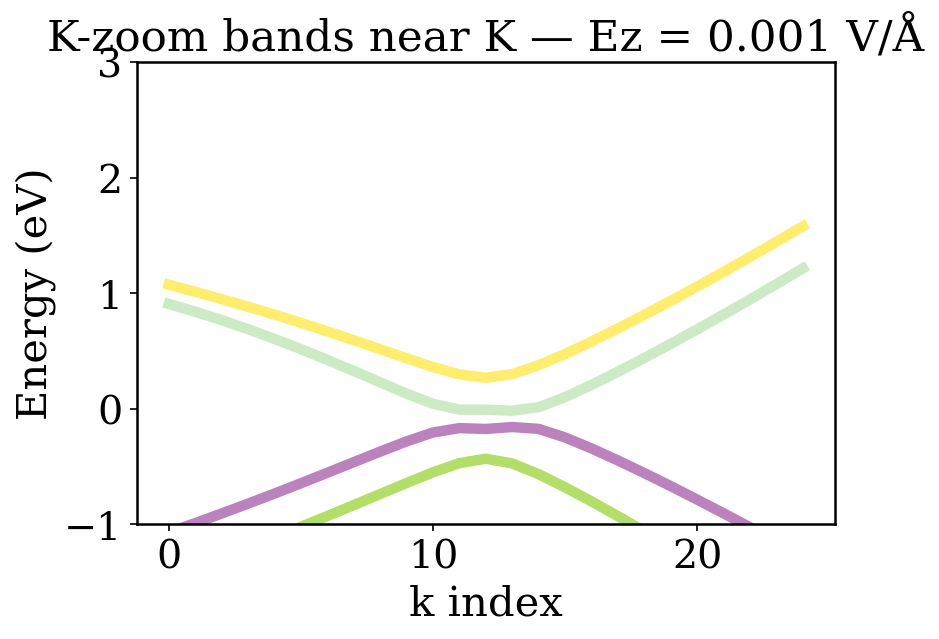

[2026-01-03 12:49:14] Ez=0.001 -> gap=0.141658 eV


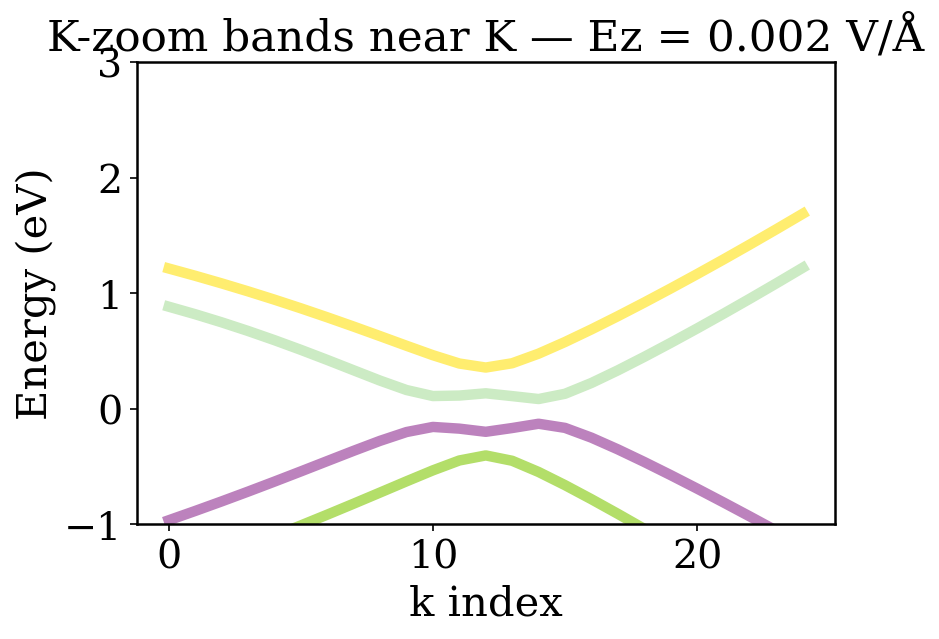

[2026-01-03 12:49:15] Ez=0.002 -> gap=0.214046 eV


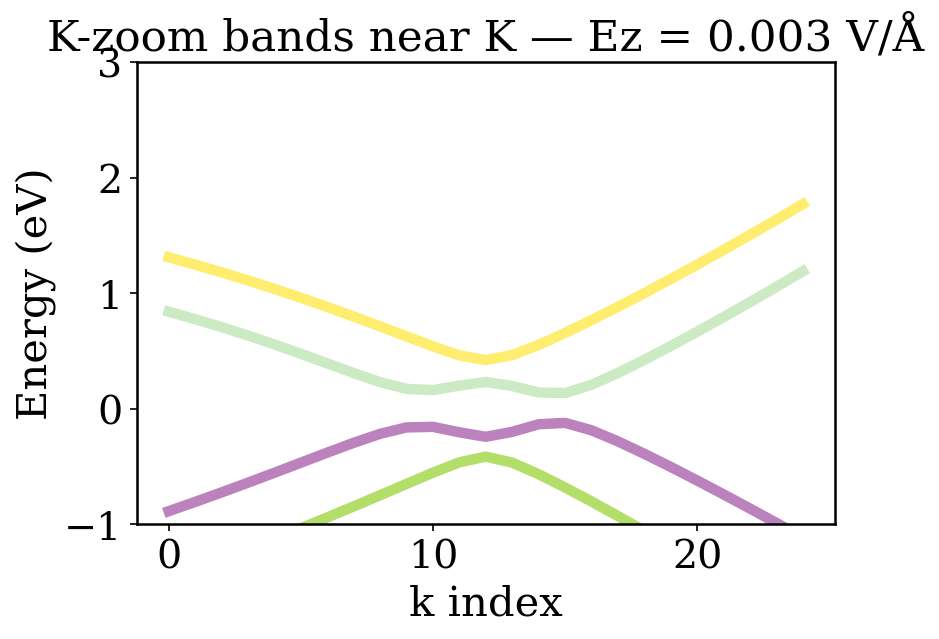

[2026-01-03 12:49:15] Ez=0.003 -> gap=0.258743 eV


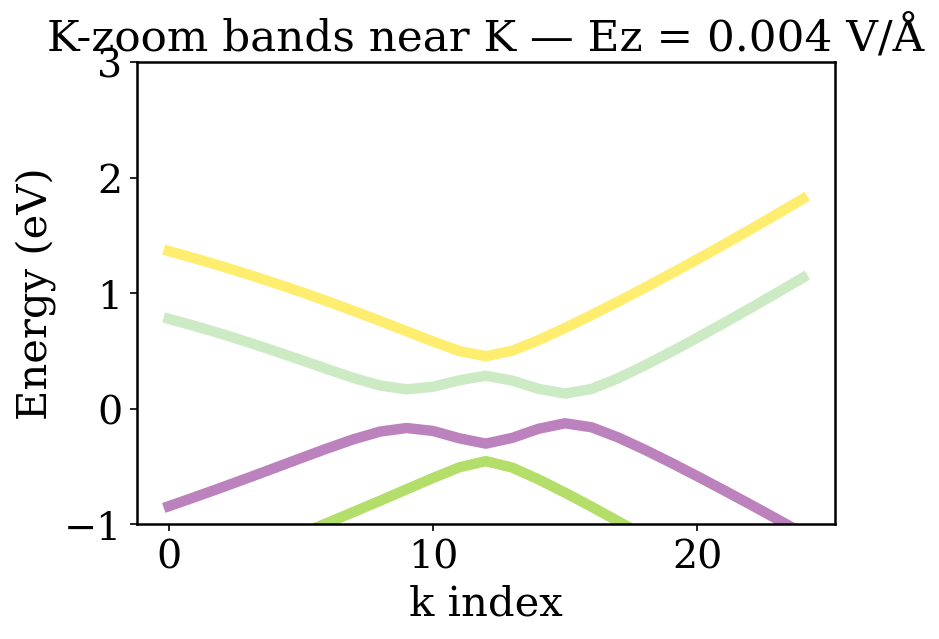

[2026-01-03 12:49:15] Ez=0.004 -> gap=0.257285 eV


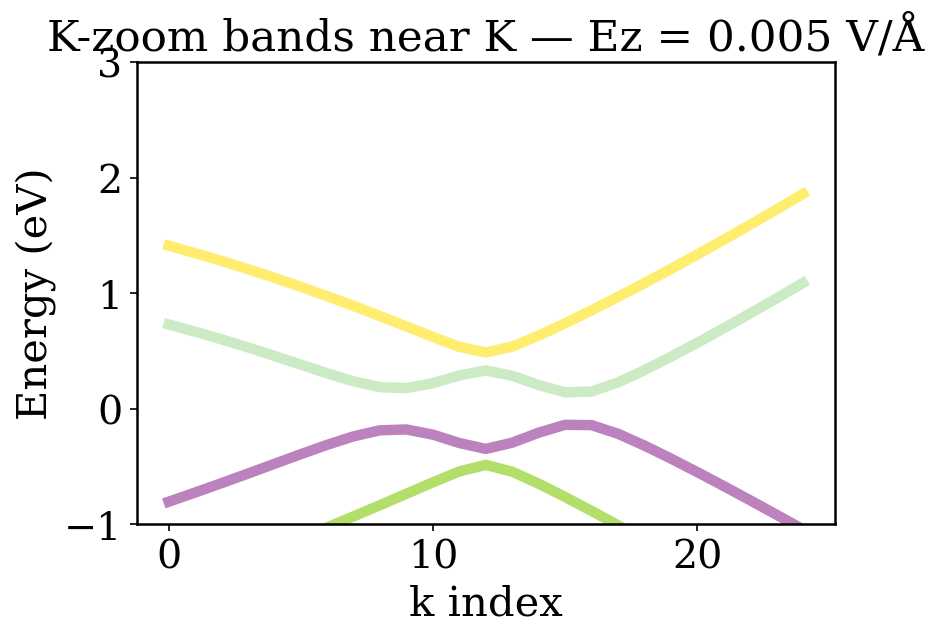

[2026-01-03 12:49:15] Ez=0.005 -> gap=0.281438 eV


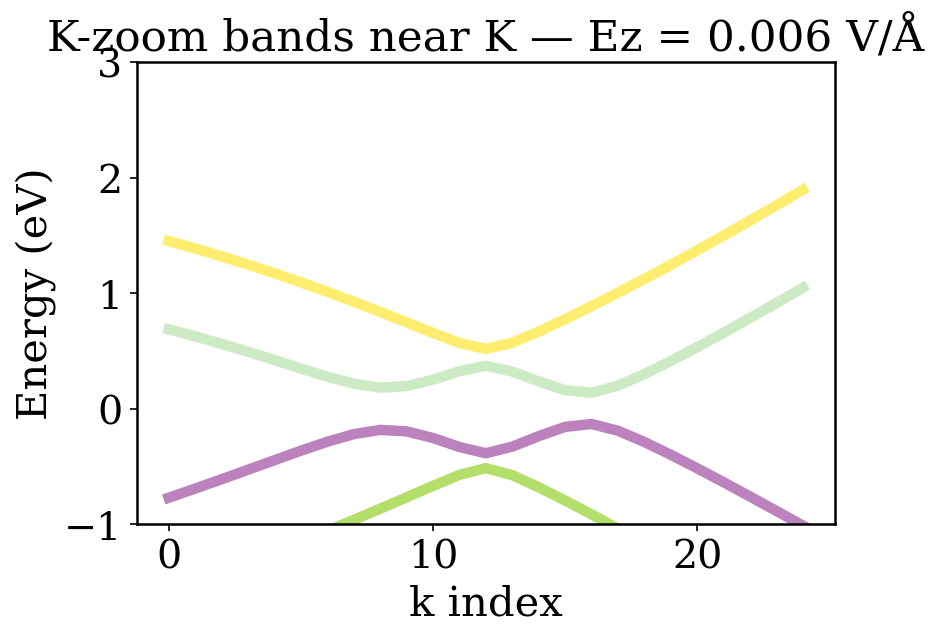

[2026-01-03 12:49:16] Ez=0.006 -> gap=0.270422 eV


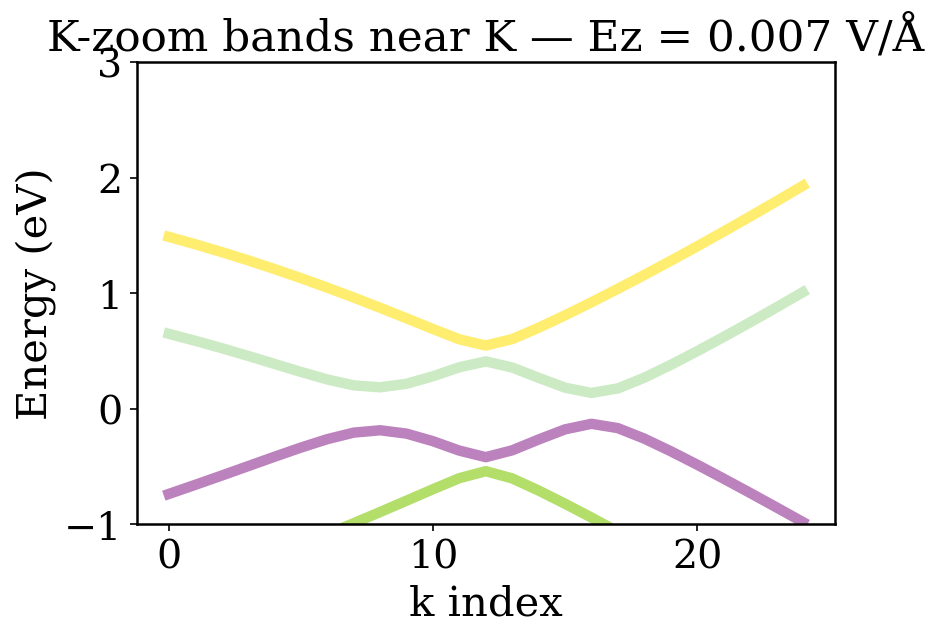

[2026-01-03 12:49:16] Ez=0.007 -> gap=0.267275 eV


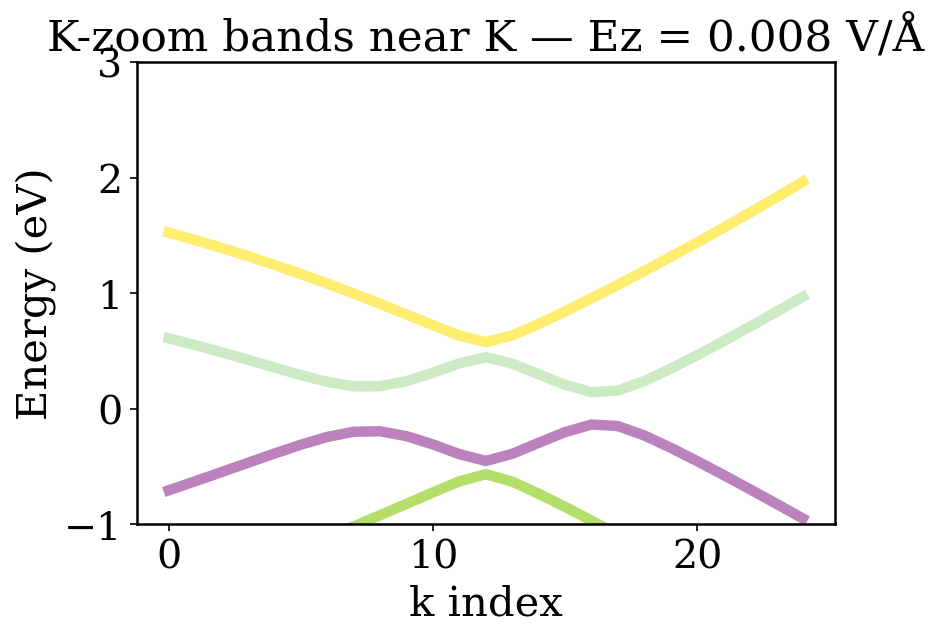

[2026-01-03 12:49:16] Ez=0.008 -> gap=0.280257 eV


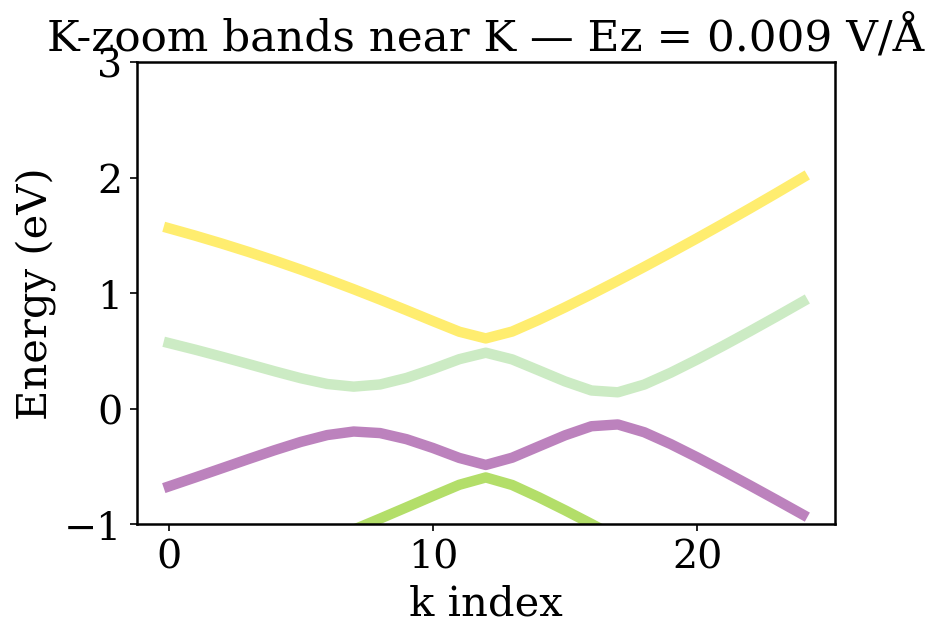

[2026-01-03 12:49:16] Ez=0.009 -> gap=0.278390 eV


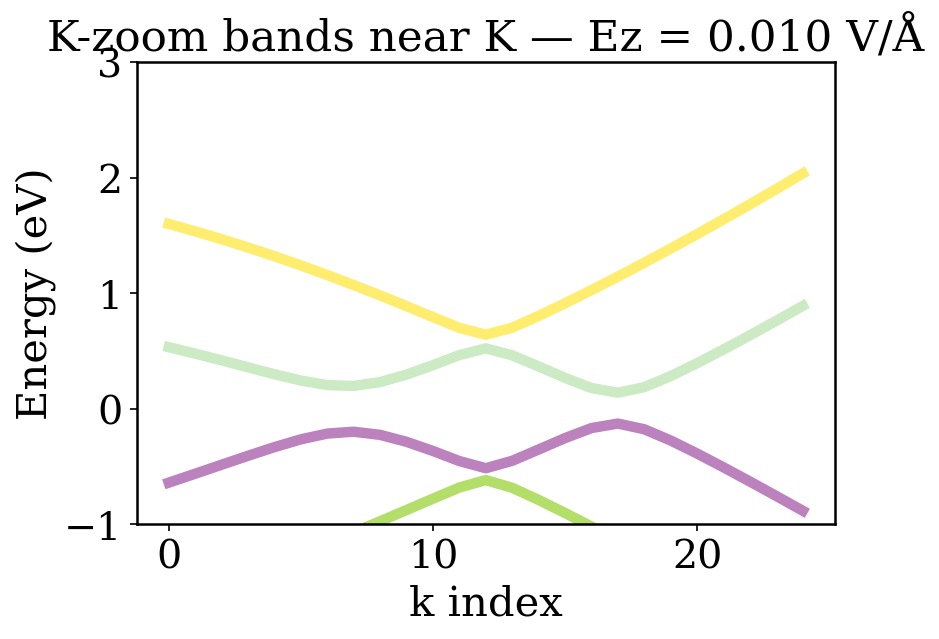

[2026-01-03 12:49:17] Ez=0.010 -> gap=0.267196 eV


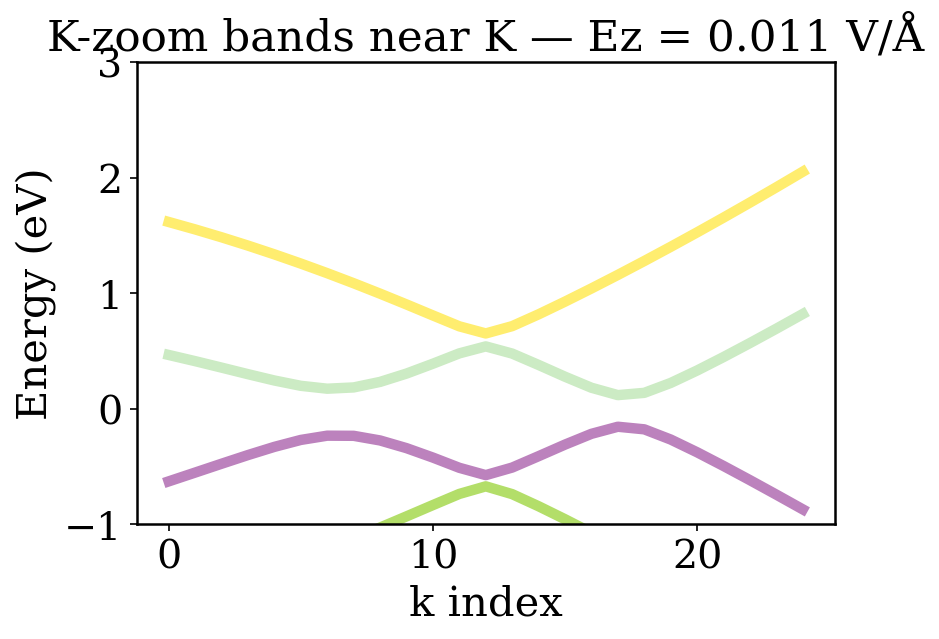

[2026-01-03 12:49:17] Ez=0.011 -> gap=0.273793 eV


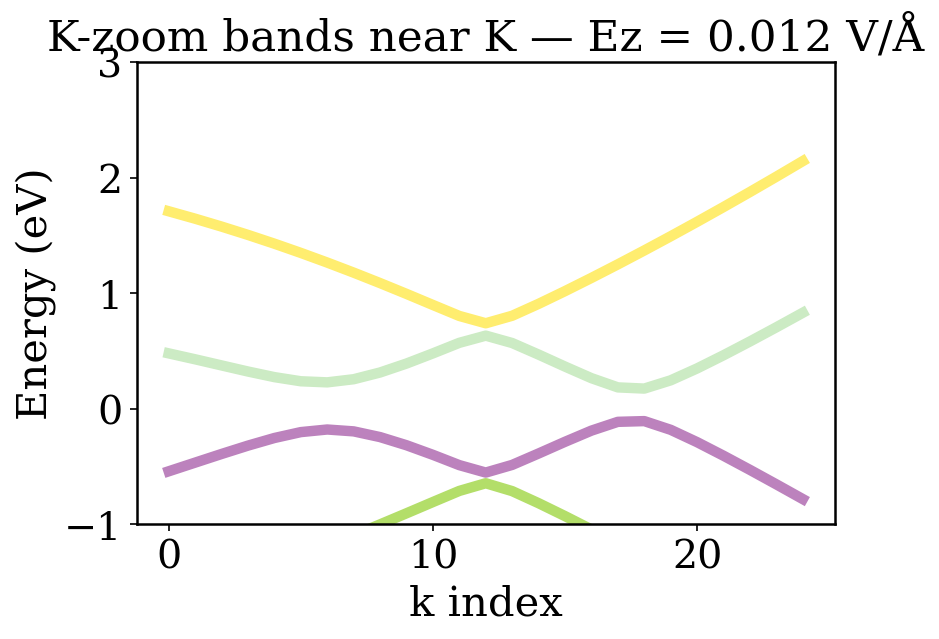

[2026-01-03 12:49:17] Ez=0.012 -> gap=0.281630 eV


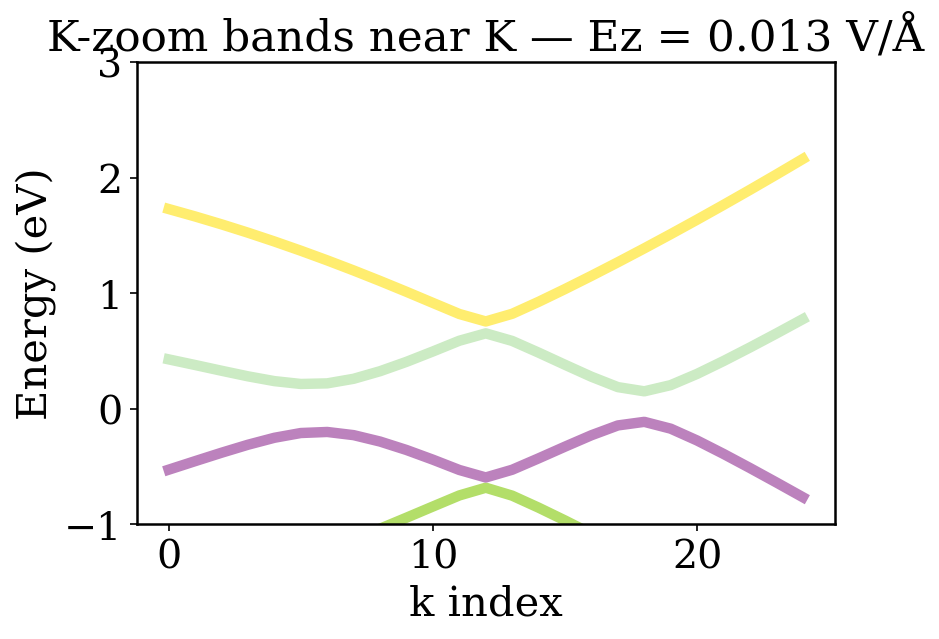

[2026-01-03 12:49:17] Ez=0.013 -> gap=0.264365 eV


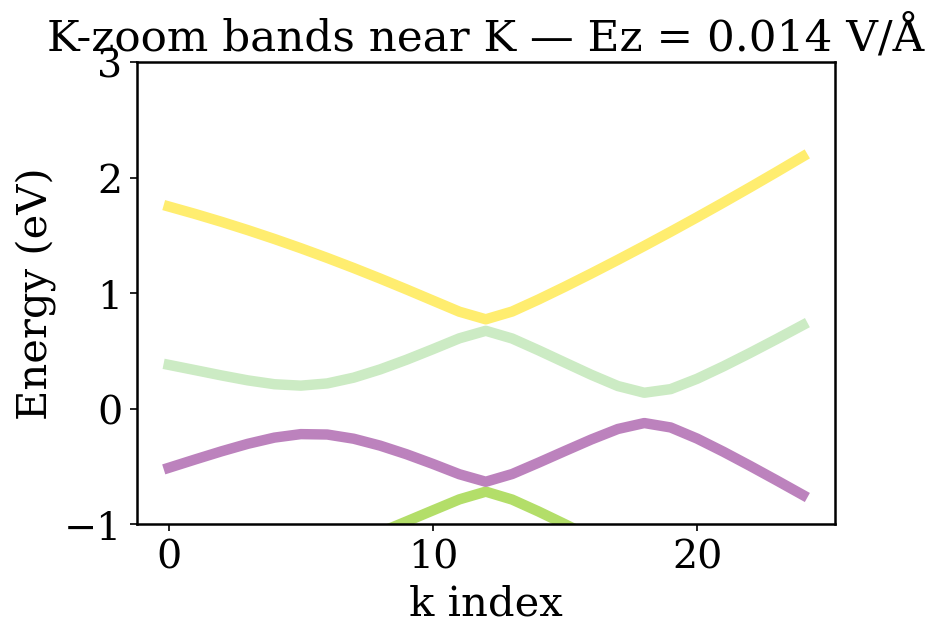

[2026-01-03 12:49:18] Ez=0.014 -> gap=0.262372 eV


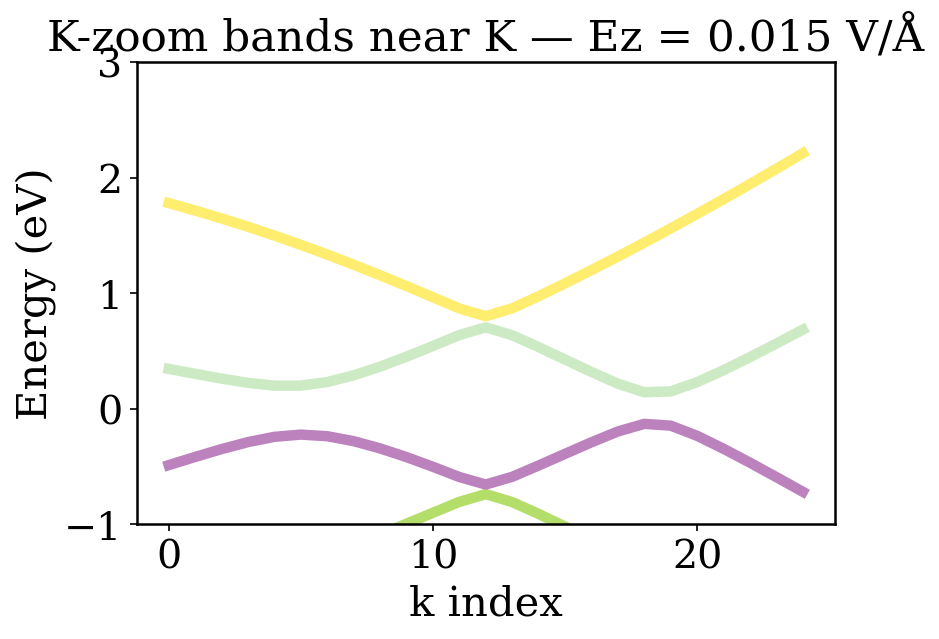

[2026-01-03 12:49:18] Ez=0.015 -> gap=0.273868 eV


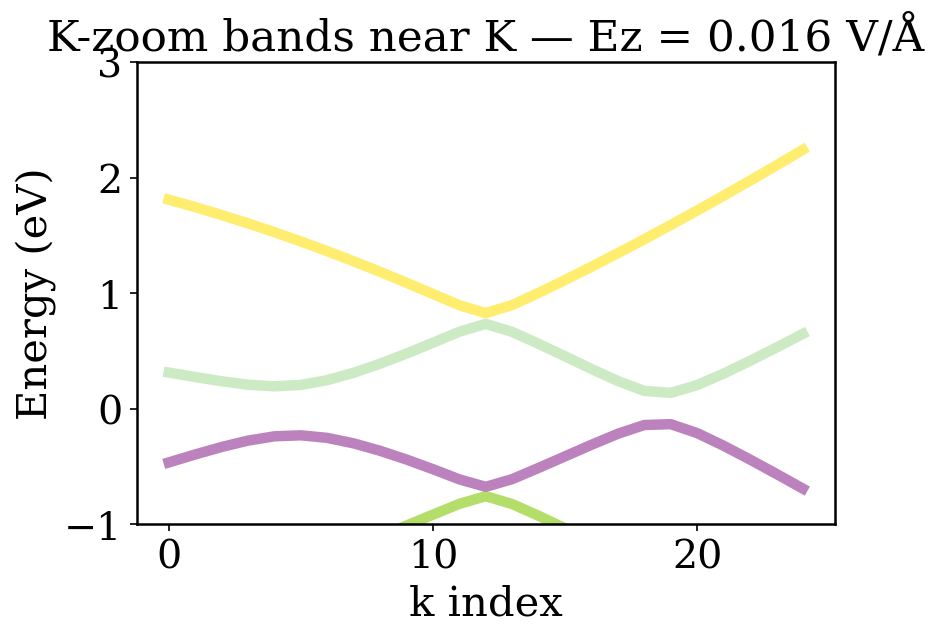

[2026-01-03 12:49:18] Ez=0.016 -> gap=0.270888 eV


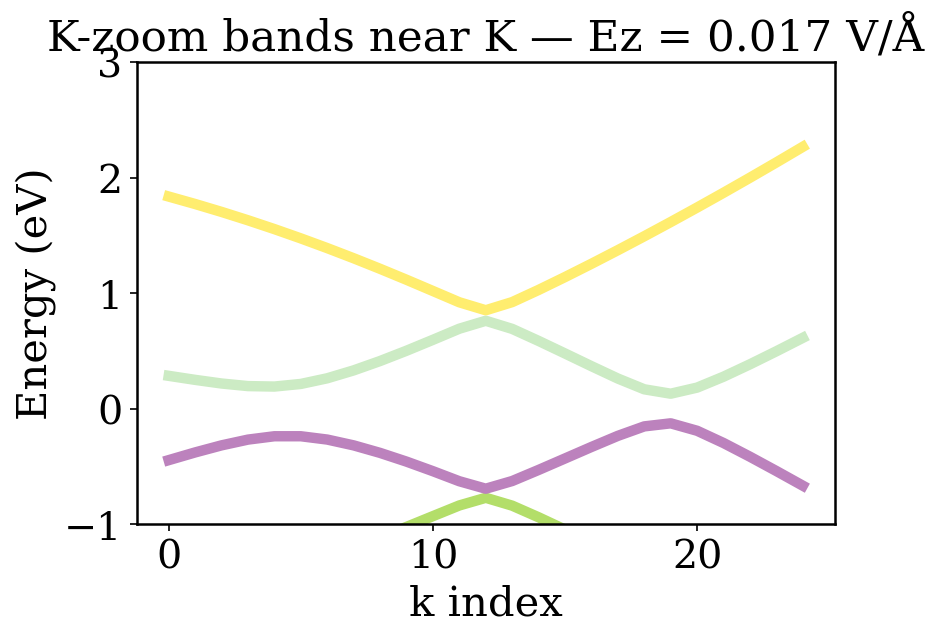

[2026-01-03 12:49:19] Ez=0.017 -> gap=0.256510 eV


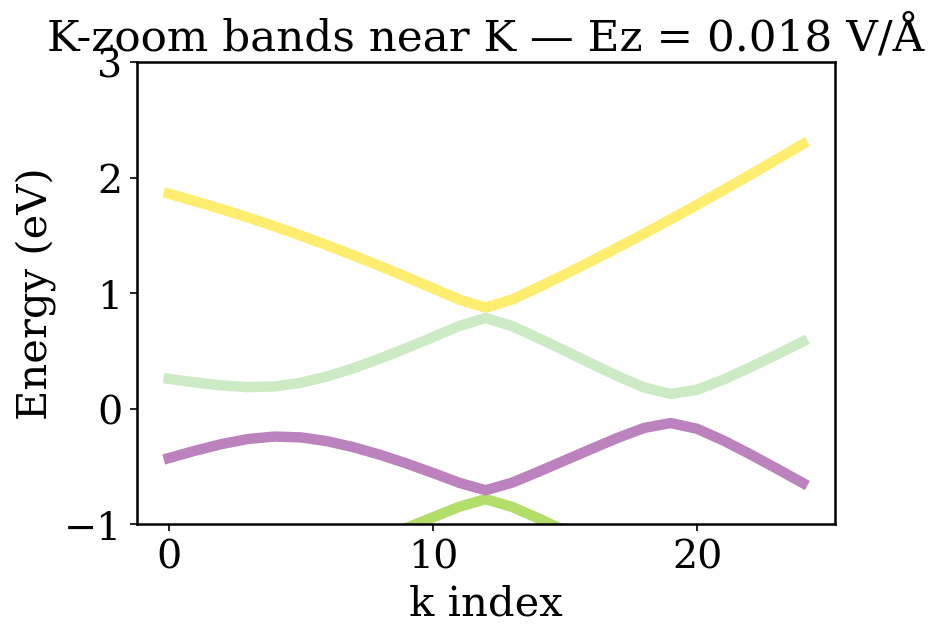

[2026-01-03 12:49:19] Ez=0.018 -> gap=0.251745 eV


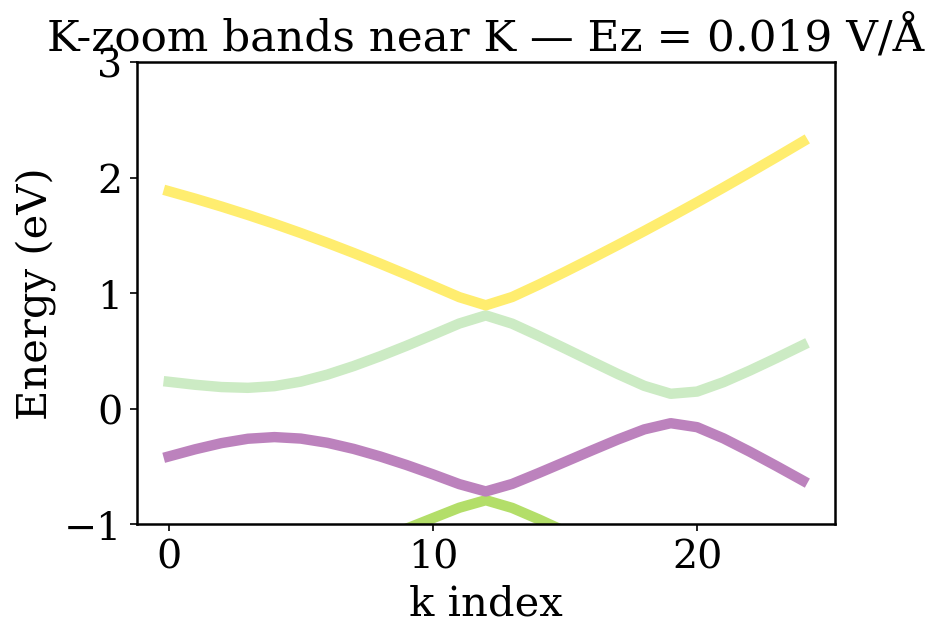

[2026-01-03 12:49:19] Ez=0.019 -> gap=0.254610 eV


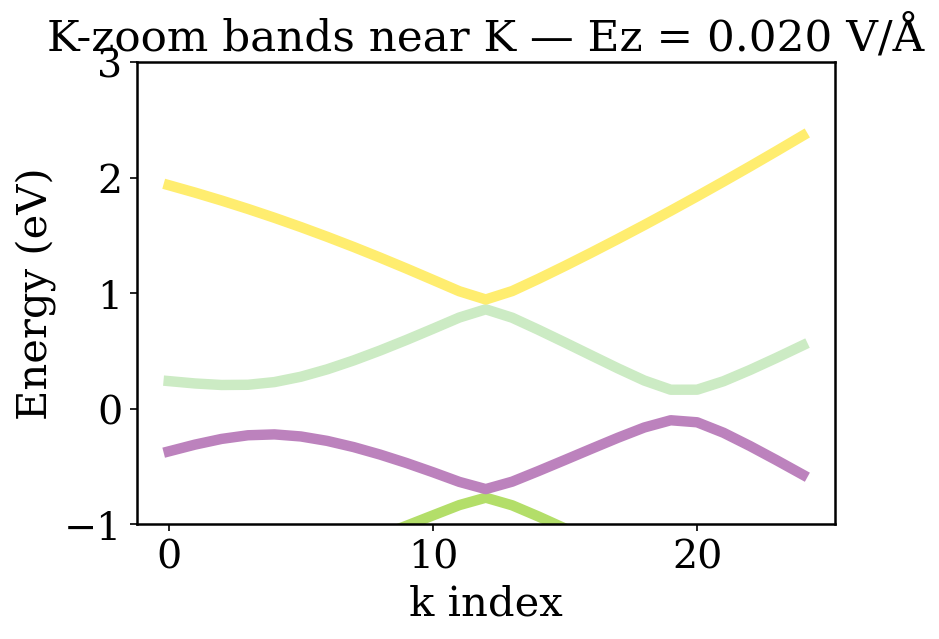

[2026-01-03 12:49:20] Ez=0.020 -> gap=0.264320 eV


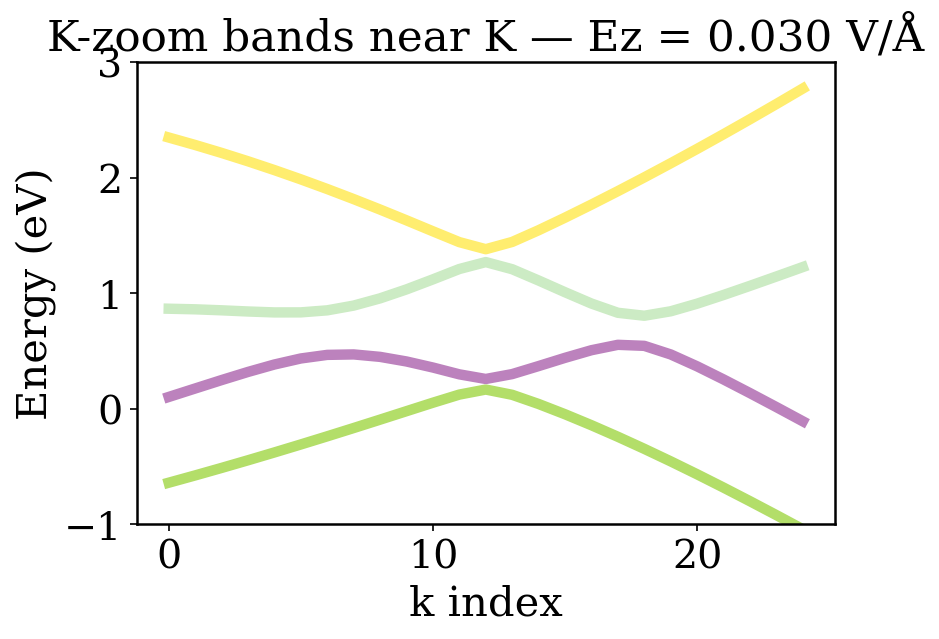

[2026-01-03 12:49:20] Ez=0.030 -> gap=0.000000 eV


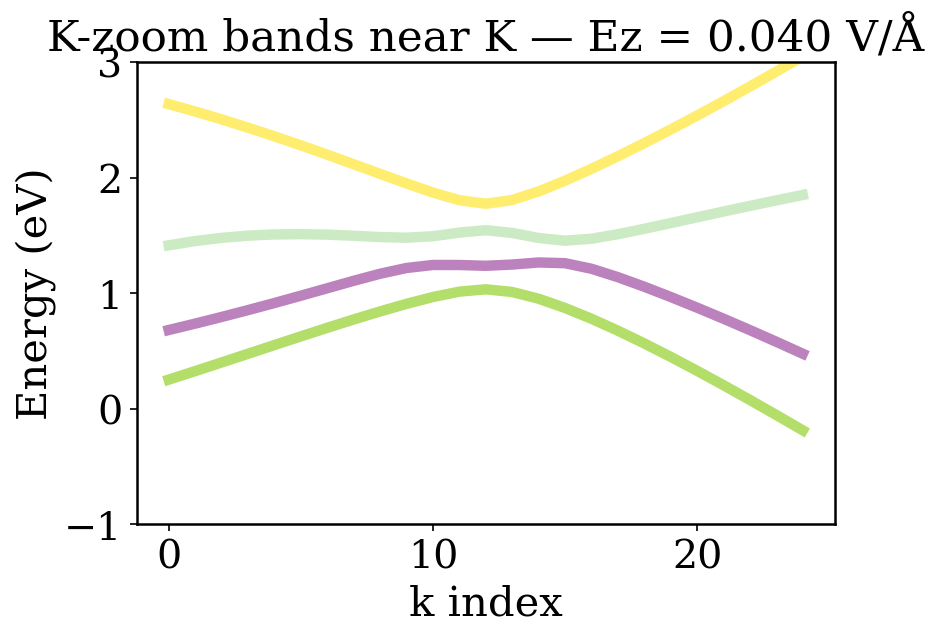

[2026-01-03 12:49:20] Ez=0.040 -> gap=7.554165 eV


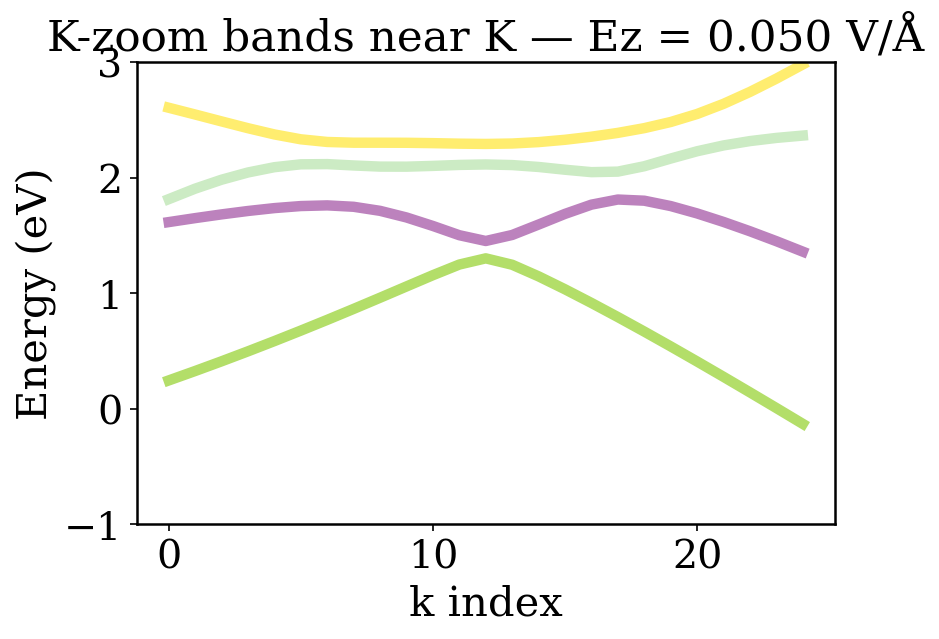

[2026-01-03 12:49:20] Ez=0.050 -> gap=7.606758 eV


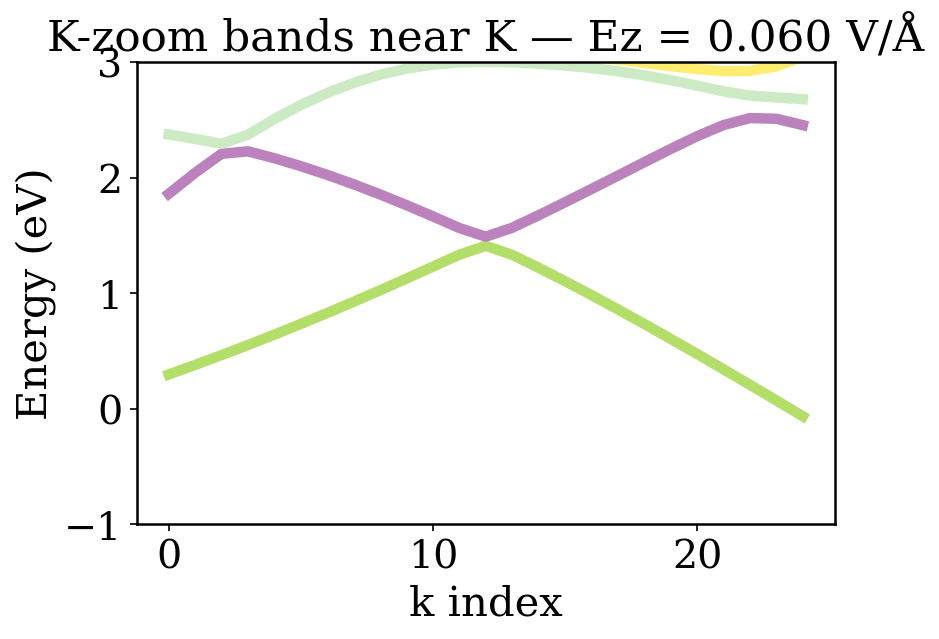

[2026-01-03 12:49:20] Ez=0.060 -> gap=7.537424 eV


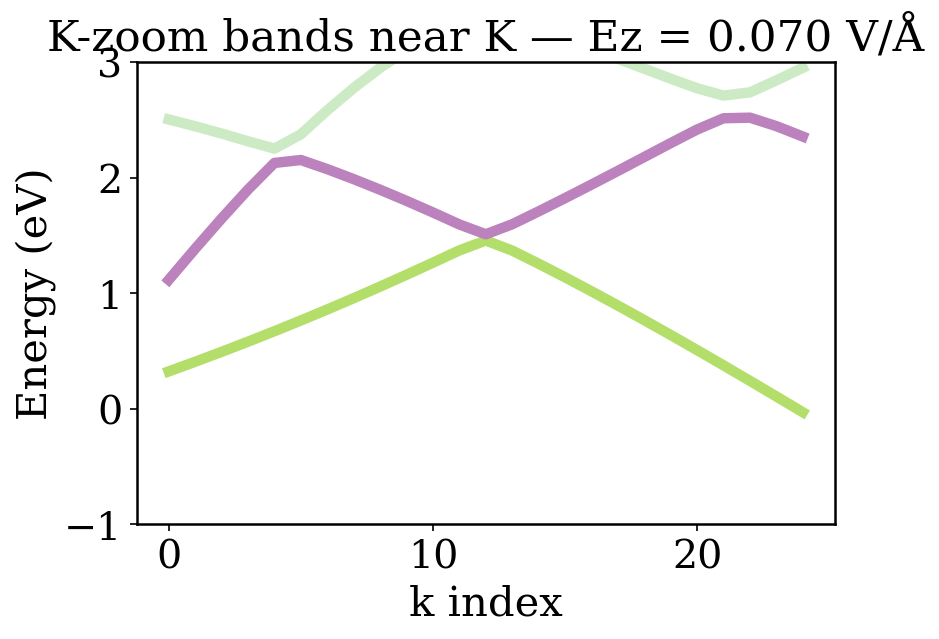

[2026-01-03 12:49:21] Ez=0.070 -> gap=7.455643 eV


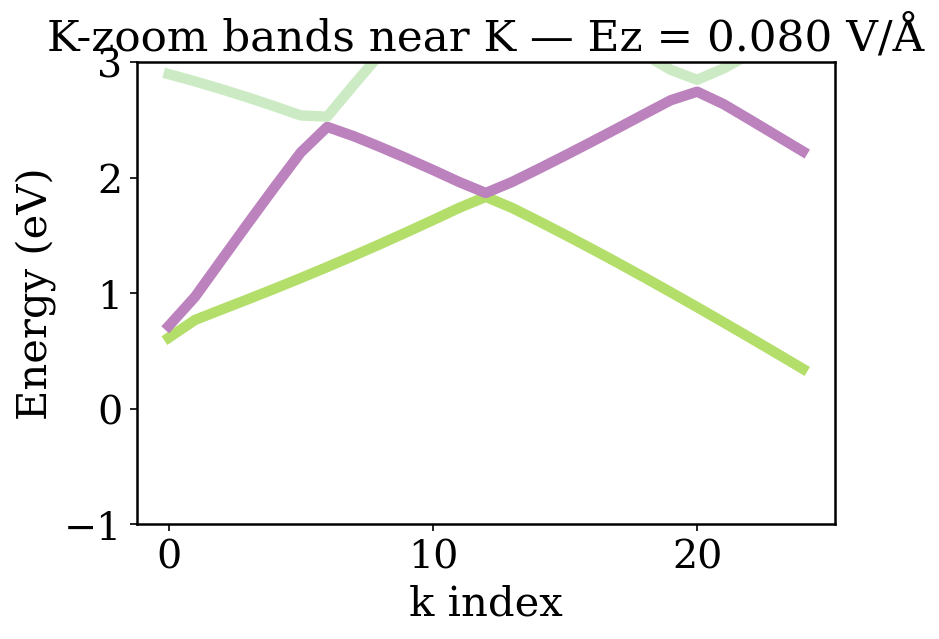

[2026-01-03 12:49:21] Ez=0.080 -> gap=7.459366 eV


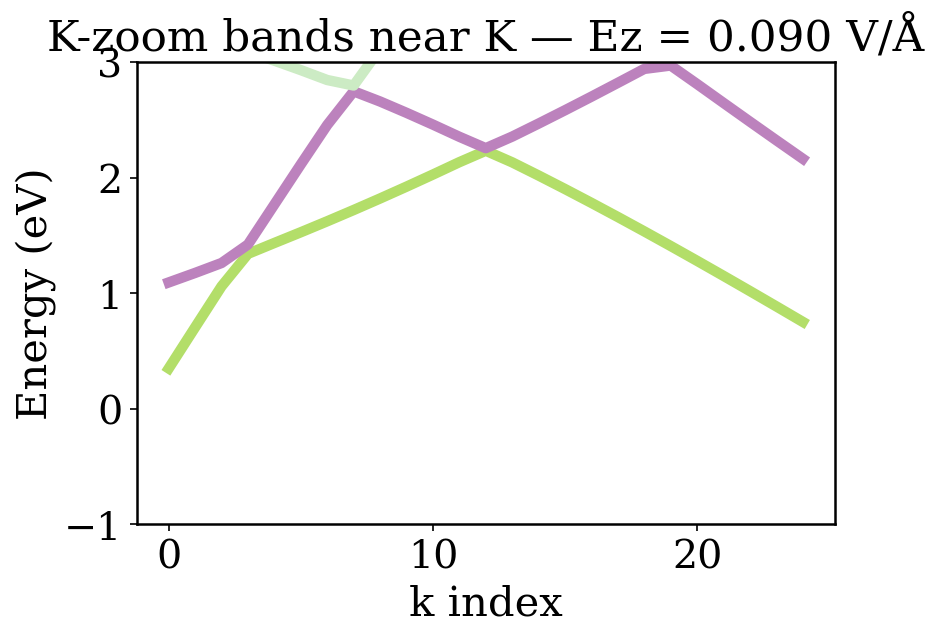

[2026-01-03 12:49:21] Ez=0.090 -> gap=7.132647 eV


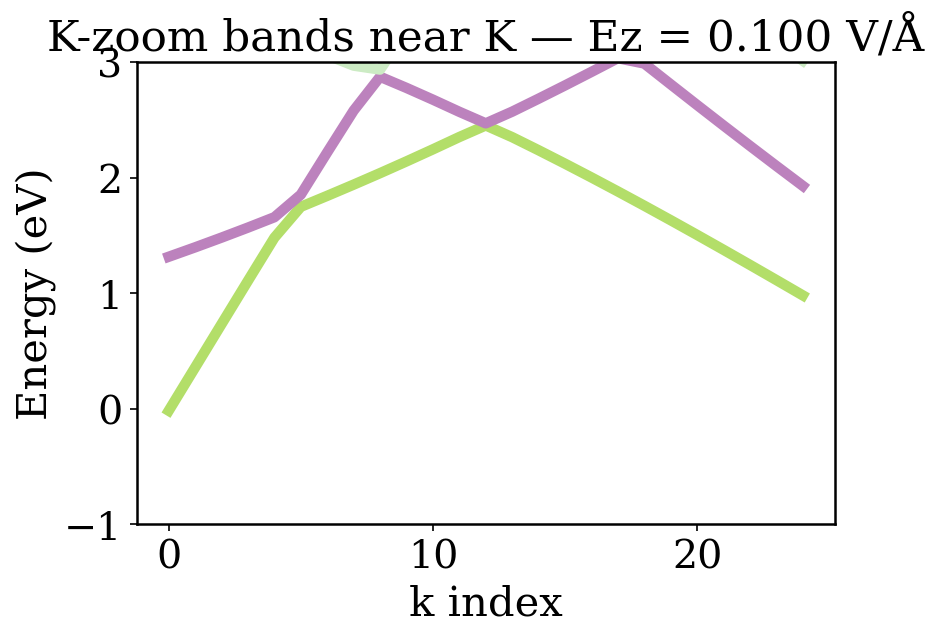

[2026-01-03 12:49:22] Ez=0.100 -> gap=6.628870 eV


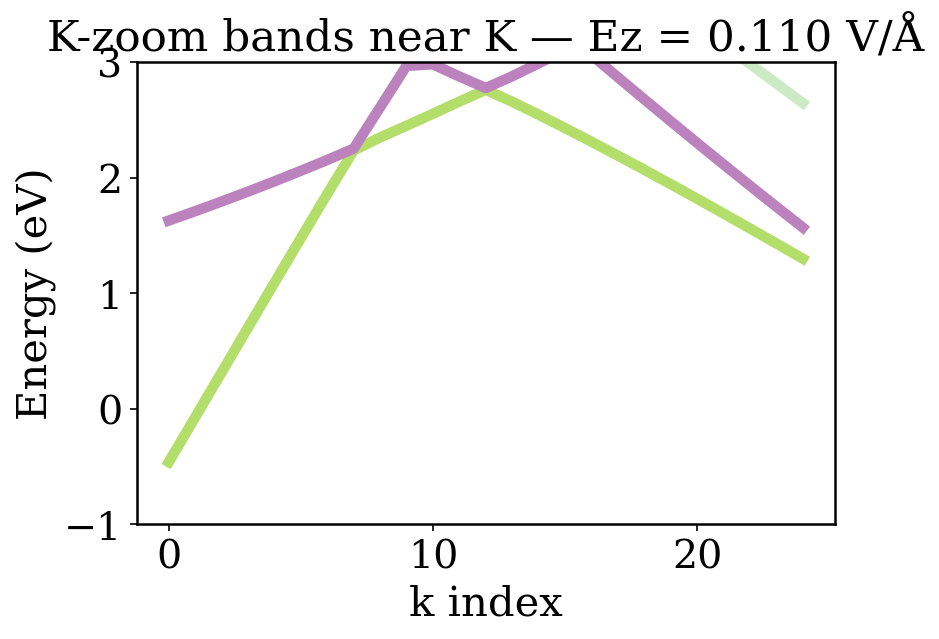

[2026-01-03 12:49:22] Ez=0.110 -> gap=5.962137 eV


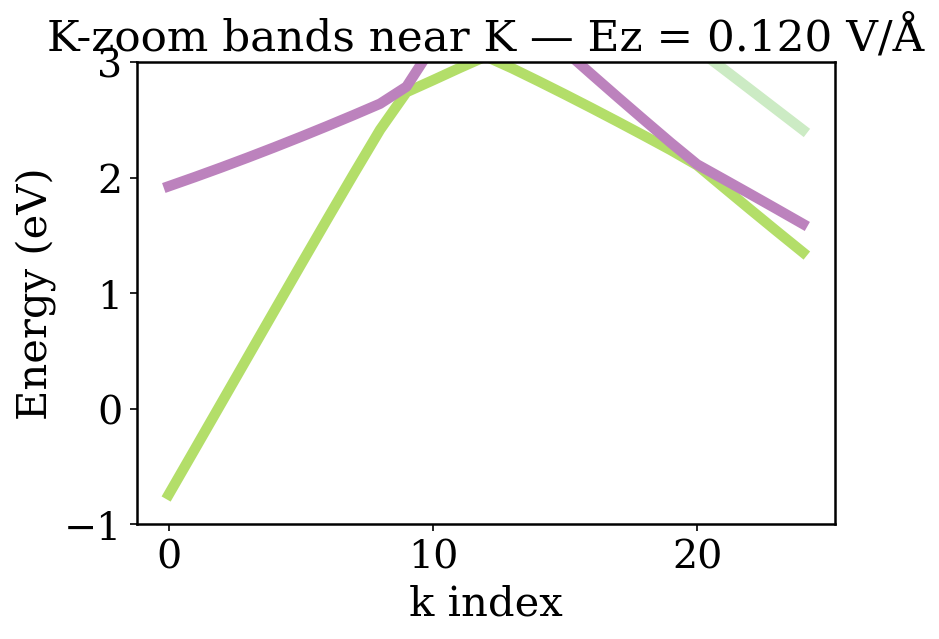

[2026-01-03 12:49:22] Ez=0.120 -> gap=5.514870 eV


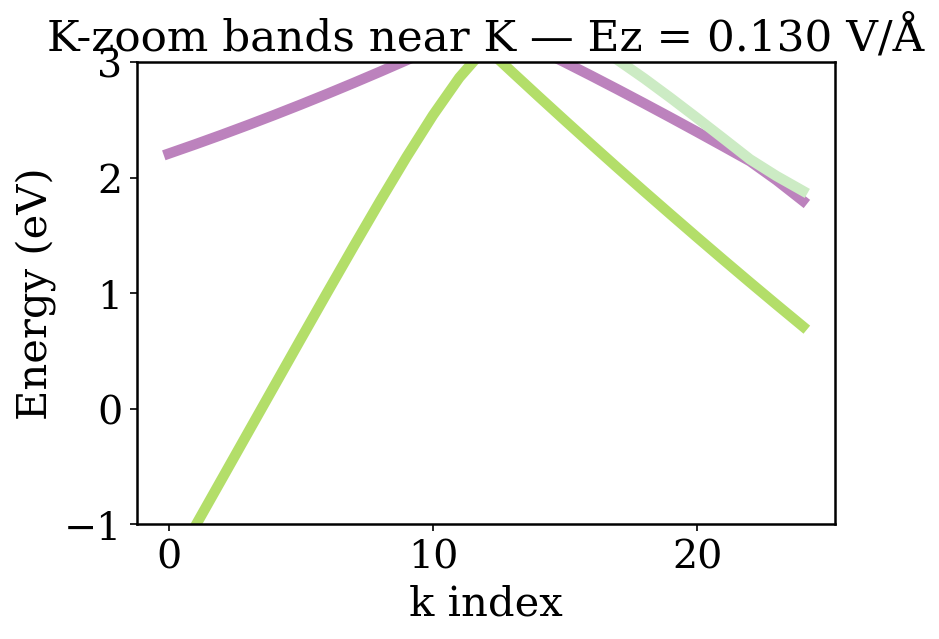

[2026-01-03 12:49:22] Ez=0.130 -> gap=4.668971 eV


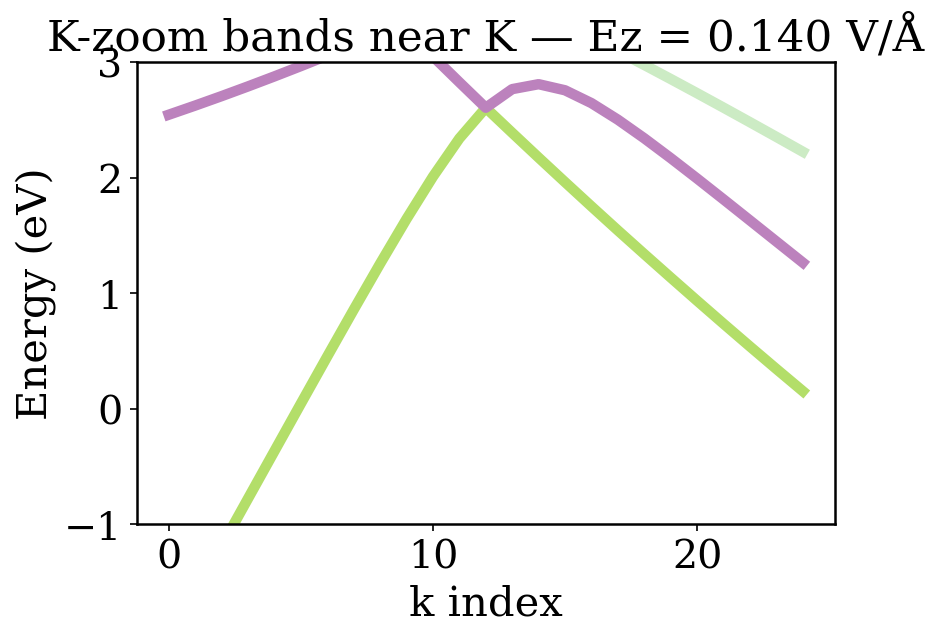

[2026-01-03 12:49:23] Ez=0.140 -> gap=3.877807 eV


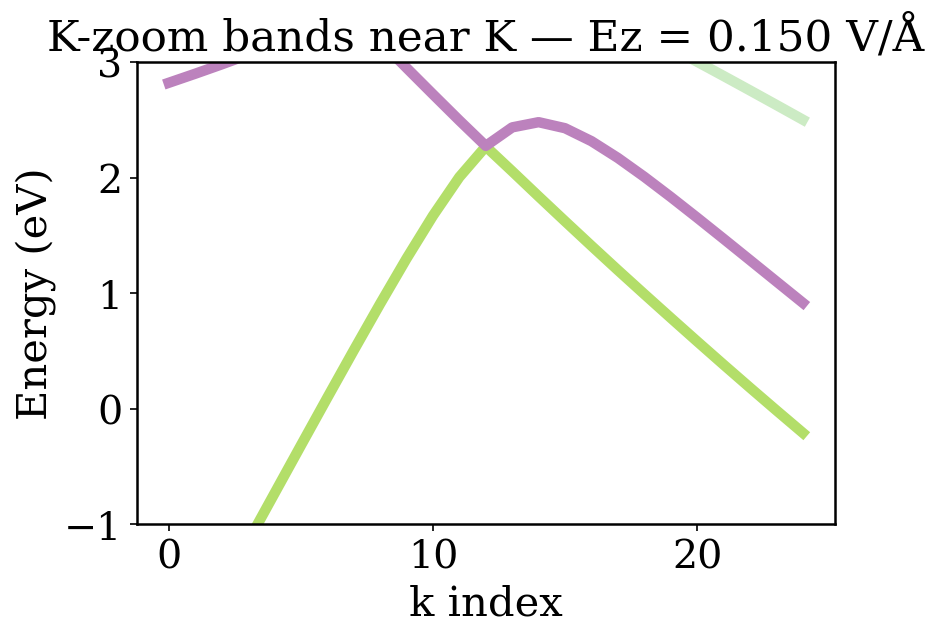

[2026-01-03 12:49:23] Ez=0.150 -> gap=3.363392 eV


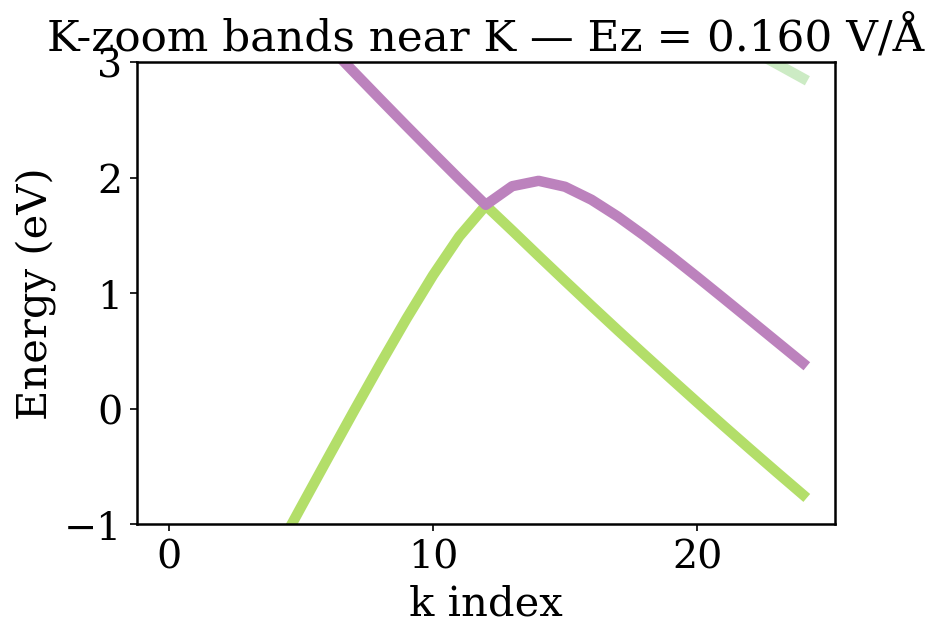

[2026-01-03 12:49:23] Ez=0.160 -> gap=2.596638 eV


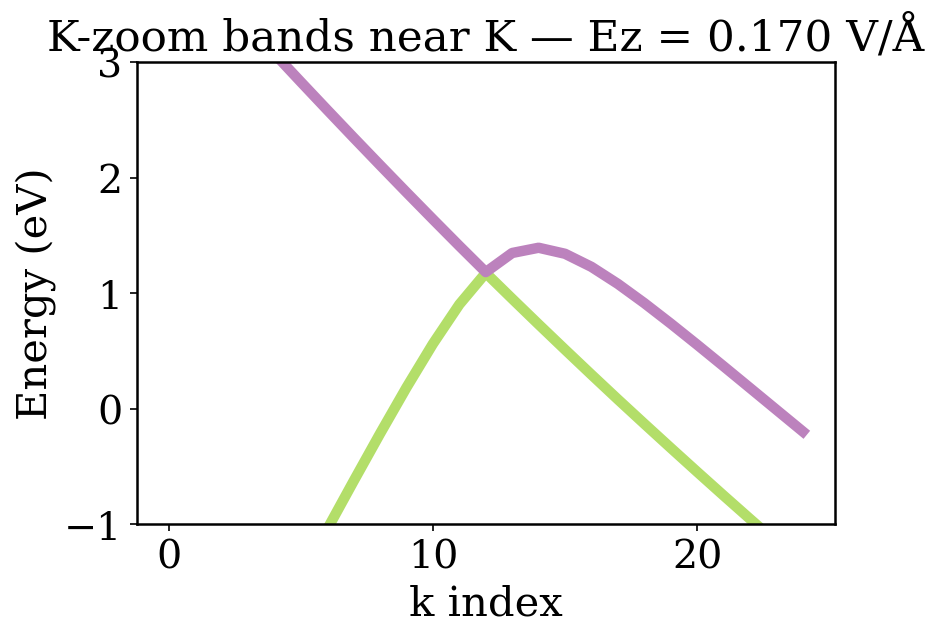

[2026-01-03 12:49:23] Ez=0.170 -> gap=0.000000 eV


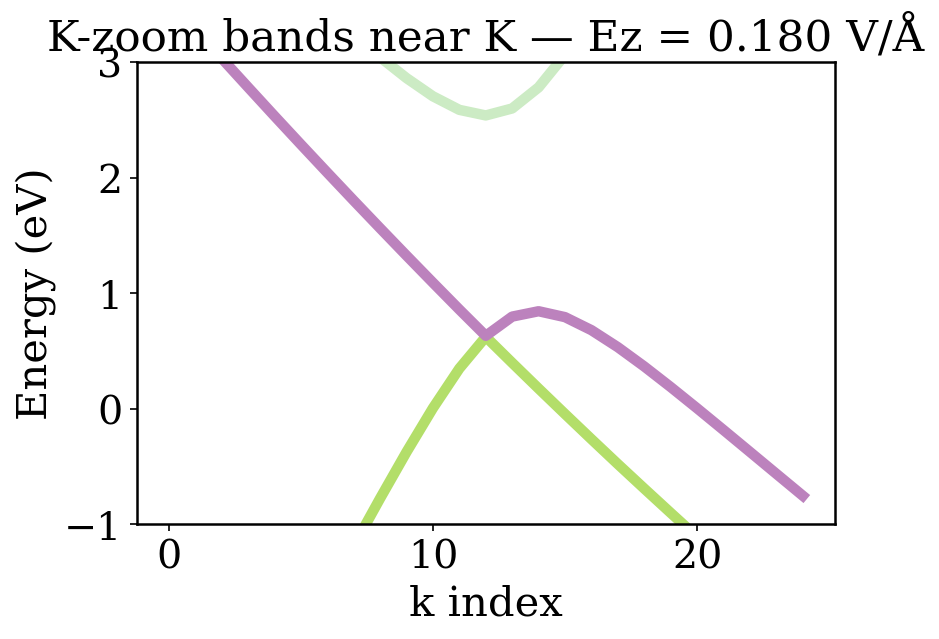

[2026-01-03 12:49:24] Ez=0.180 -> gap=0.000000 eV


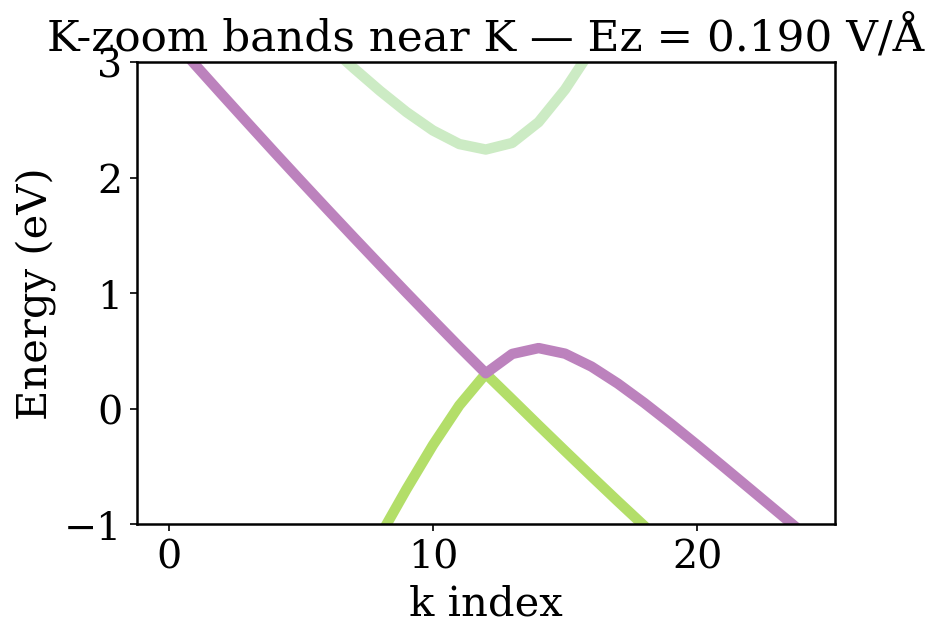

[2026-01-03 12:49:24] Ez=0.190 -> gap=0.000000 eV


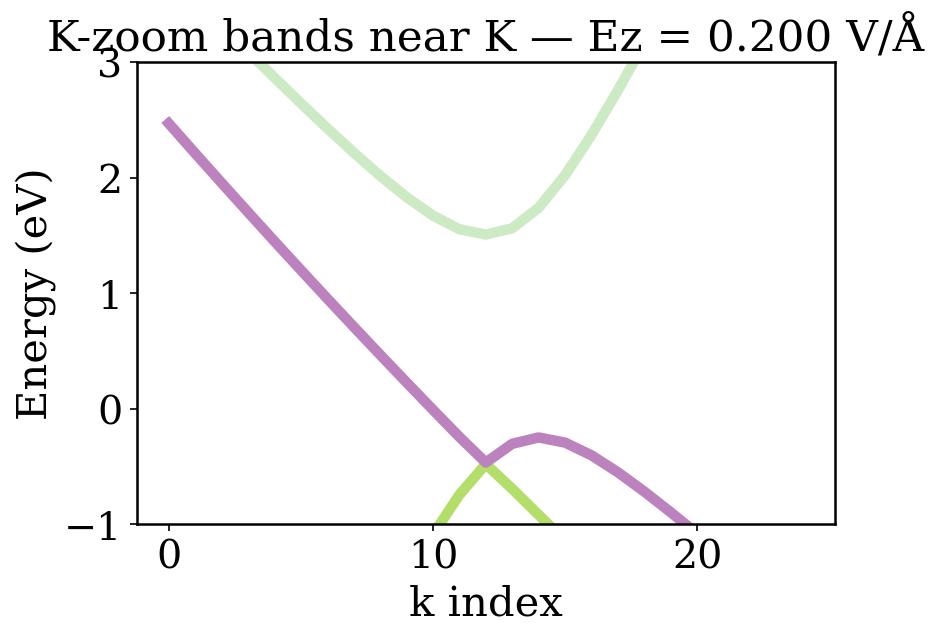

[2026-01-03 12:49:24] Ez=0.200 -> gap=0.000000 eV


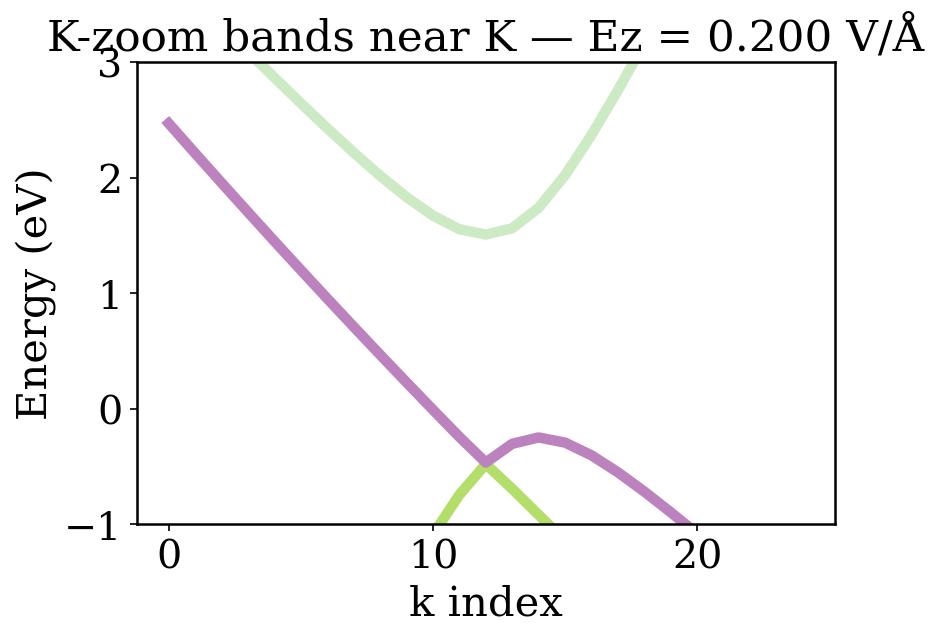

[2026-01-03 12:49:24] Ez=0.200 -> gap=0.000000 eV


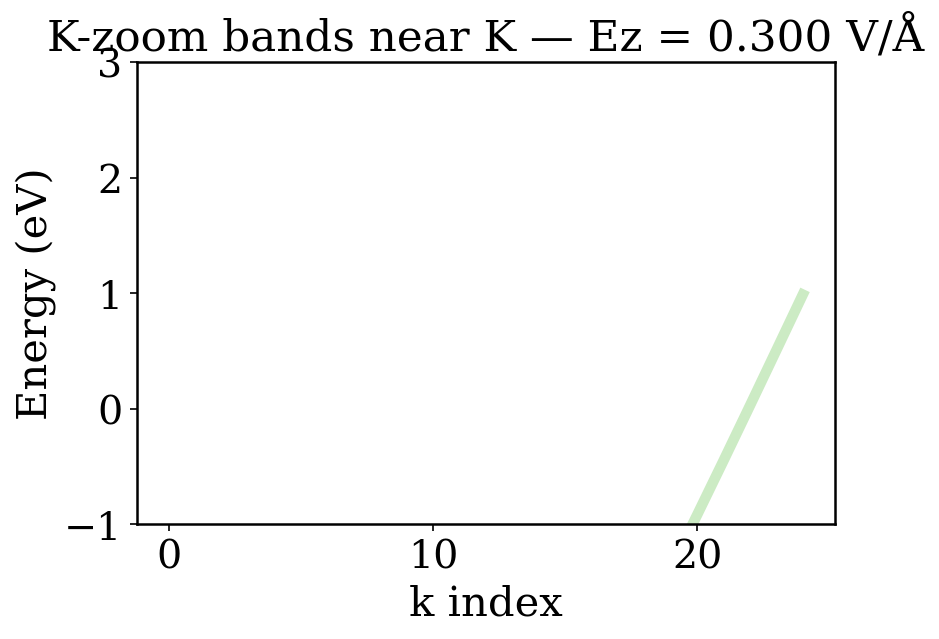

[2026-01-03 12:49:25] Ez=0.300 -> gap=4.547623 eV


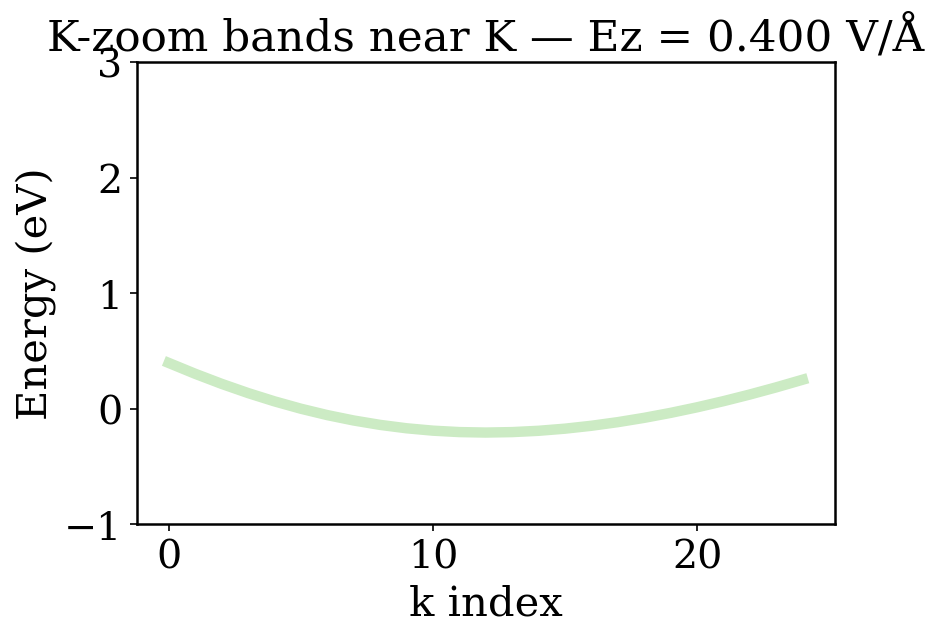

[2026-01-03 12:49:25] Ez=0.400 -> gap=4.439322 eV


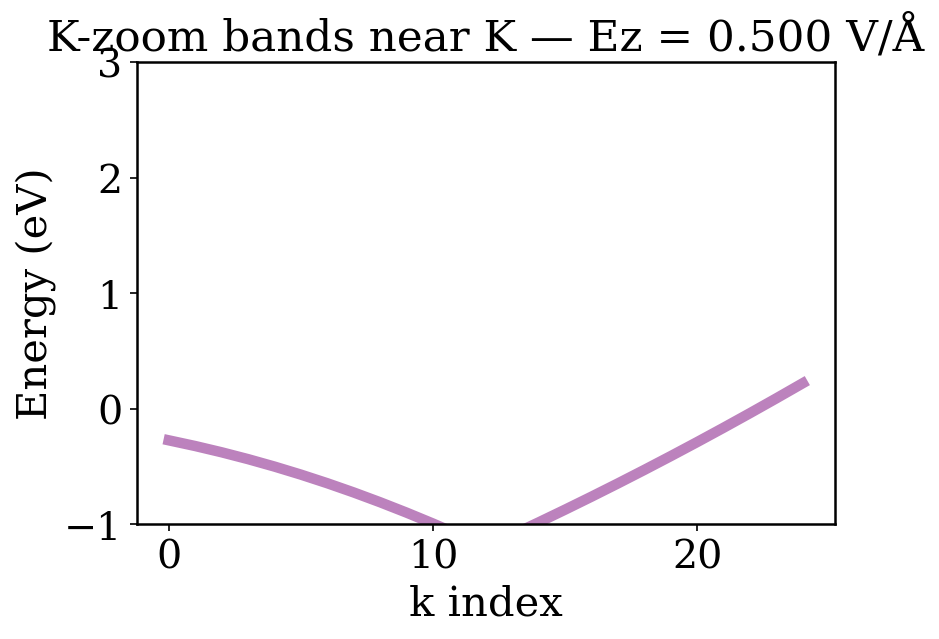

[2026-01-03 12:49:25] Ez=0.500 -> gap=3.957352 eV
[2026-01-03 12:49:25] Saved band gaps to ../gpw/bandgaps_KZOOM.csv


In [24]:
import os
import numpy as np
import csv
from ase.dft.bandgap import bandgap

# Output CSV (simple and plot-friendly)
gap_csv = os.path.join(out_dir, "bandgaps_KZOOM.csv")

results = []

fields_from_csv = np.array(fields_from_csv, dtype=object)
mask = fields_from_csv[:, 0].astype(float) >= 0#< 0.1
fields_from_csv = fields_from_csv[mask]

import numpy as np

def classify_bands_by_majority(eigs, tol=1e-6):
    """
    Returns indices of valence and conduction bands.
    """
    nk, nb = eigs.shape

    frac_above = np.mean(eigs >  tol, axis=0)
    frac_below = np.mean(eigs < -tol, axis=0)

    valence_bands = np.where(frac_below > 0.5)[0]
    conduction_bands = np.where(frac_above > 0.5)[0]

    return valence_bands, conduction_bands


# order by Ez
idx = np.argsort(fields_from_csv[:, 0].astype(float))
fields_from_csv = fields_from_csv[idx]

for Ez, gpw_Ez in fields_from_csv:
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f"ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz")

    if not os.path.exists(npz_Ez):
        log(f"K-zoom NPZ missing for Ez={Ez:.3f} — skipping gap")
        continue

    data = np.load(npz_Ez)
    E = data["E"]        # shape: (Nk, nbands), already shifted by EF

    # ---- band selection (as requested) ----
    # upper band closest to 0

    valence, conduction = classify_bands_by_majority(E)

    vbm = np.max(E[:, valence])
    cbm = np.min(E[:, conduction])

    gap = max(0.0, cbm - vbm)

    plt.cla()
    for n in range(E.shape[1]):
        plt.plot(E[:, n])
    plt.ylim(-1, 3)
    plt.title(f"K-zoom bands near K — Ez = {Ez:.3f} V/Å")
    plt.xlabel("k index")
    plt.ylabel("Energy (eV)")
    plt.show()

    results.append((Ez, gap))
    log(f"Ez={Ez:.3f} -> gap={gap:.6f} eV")

# ---- save to CSV ----
with open(gap_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Ez", "bandgap_eV"])
    writer.writerows(results)

log(f"Saved band gaps to {gap_csv}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


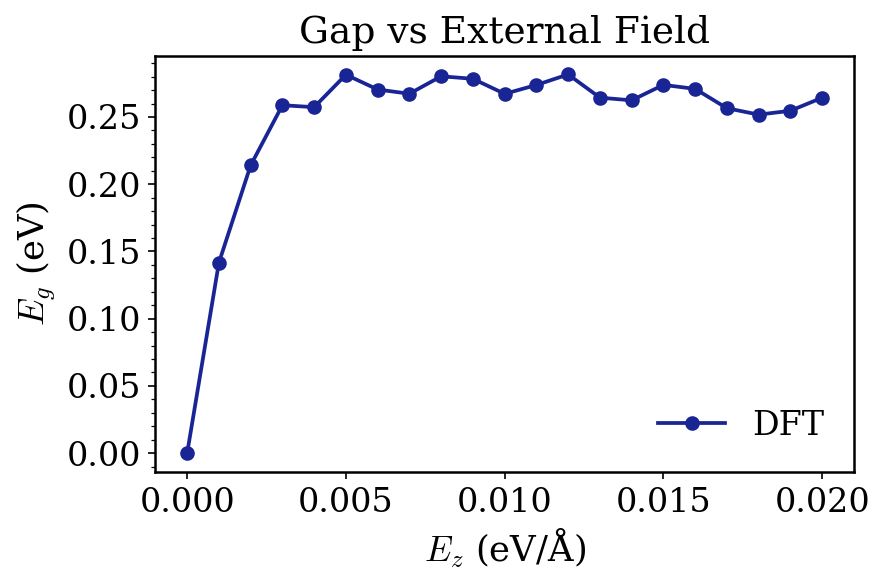

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import os
from common.mpl_style import set_mpl_style

# ----------------------------------
# Styling
# ----------------------------------
set_mpl_style()

gap_csv = os.path.join(out_dir, "bandgaps_KZOOM.csv")

Ez_vals = []
gaps = []

with open(gap_csv, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        Ez_vals.append(float(row["Ez"]))
        gaps.append(float(row["bandgap_eV"]))

Ez_vals = np.array(Ez_vals)
gaps = np.array(gaps)

# sort by field
#Ez_vals_filtered = Ez_vals[Ez_vals < 0.025]
#gaps_filtered = gaps[Ez_vals < 0.025]
#idx = np.array(Ez_vals)
#idx = idx[Ez_vals < 0.001]
#idx = np.argsort(idx)
import matplotlib as mpl
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
from common.mpl_style import set_mpl_style
idx = np.argsort(Ez_vals)
Ez_vals_filtered = Ez_vals[idx]
gaps_filtered = gaps[idx]

mask = Ez_vals_filtered < 0.023
Ez_vals_filtered = Ez_vals_filtered[mask]
gaps_filtered = gaps_filtered[mask]

# ---- plot ----
#set_mpl_style()
set_mpl_style()

from matplotlib.ticker import MultipleLocator




plt.figure(figsize=(6, 4))
plt.plot(Ez_vals_filtered, gaps_filtered, marker="o", color='#192594', label='DFT')
plt.xlabel(r"$E_z$ (eV/Å)")
plt.ylabel(r"$E_g$ (eV)")
plt.title("Gap vs External Field")
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.05))   # major ticks every 0.05 eV
ax.yaxis.set_minor_locator(MultipleLocator(0.01))   # minor ticks every 0.01 eV

from matplotlib.ticker import FormatStrFormatter

#plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig('../data/band_gap_vs_field.pdf', dpi=500)
#set_mpl_style()
plt.savefig('../data/band_gap_vs_field.png', dpi=500)
plt.show()



In [10]:
idx = np.argsort(Ez_vals)
idx = idx[Ez_vals < 0.03]

Ez_vals[idx]

array([0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009,
       0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018,
       0.019, 0.02 ])

# Load saved full-path band data and PLOT for each field


In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

import numpy as np

fields_from_csv = fields_from_csv[fields_from_csv[:, 0]< 0.022]
# Convert to array for easy handling
fields_arr = np.array(fields_from_csv, dtype=object)

# Round Ez to 3 decimals (string-safe and filename-consistent)
Ez_rounded = np.round(fields_arr[:, 0].astype(float), 3)

# Build unique list, keeping first occurrence
_, unique_idx = np.unique(Ez_rounded, return_index=True)

fields_from_csv = np.array(
    [(Ez_rounded[i], fields_arr[i, 1]) for i in sorted(unique_idx)],
    dtype=object
)

gif_path = os.path.join(out_dir, "bands_KZOOM_vs_field.gif")
fps = 4

# Ensure sorted by Ez
fields_arr = np.array(fields_from_csv, dtype=object)
idx = np.argsort(fields_arr[:, 0].astype(float))
fields_sorted = fields_arr[idx]

frames = []

for _Ez, _gpw in fields_sorted:
    _Ez = float(_Ez)
    _npz_Ez = os.path.join(out_dir, f"ab_gate_plane_A{_Ez:.3f}_bands_KZOOM.npz")
    if not os.path.exists(_npz_Ez):
        log(f"Full-path NPZ not found for Ez={_Ez:.3f}: {_npz_Ez} — skipping frame")
        continue

    _data = np.load(_npz_Ez)
    _x = _data["x"]
    _E = _data["E"]

    # EXACT same plotting settings
    fig = plt.figure(figsize=(6, 4))
    # for _n in range(_E.shape[1]):
    #     plt.plot(_x, _E[:, _n])

    colors = ["#7A1F1F", "#B23A48",  "#1C6E8C", "#0B3C5D",]  # dark → lighter red

    pi_bands_index, pi_bands_vals = [], []
    for n in range(_E.shape[1]):
        if np.any((_E[:, n] > -1) & (_E[:, n] < 1)):
            pi_bands_index.append(n)
            pi_bands_vals.append(_E[5, n])

    ordered_indexes = np.argsort(pi_bands_vals)
    ordered_ns = np.array(pi_bands_index)[ordered_indexes]
   # print(ordered_ns)
    #print('for ', _Ez)
    for n in range(_E.shape[1]):
        if np.any((_E[:, n] > -1) & (_E[:, n] < 1)):
            plt.plot(_x, _E[:, n], color=colors[np.argmax(ordered_ns==n)])
    plt.ylim(-1, 1)
    plt.xlabel("kpts")
    plt.ylabel(r"$E - E_F$ (eV)")
    plt.title(f"$E_z={_Ez:.3f}$ eV/Å")
    plt.tight_layout()

    # ---- backend-safe frame extraction ----
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    frames.append(frame)

    plt.close(fig)

# write gif
if len(frames) == 0:
    log("No frames collected — GIF not written.")
else:
    imageio.mimsave(gif_path, frames, fps=fps)
    log(f"Saved GIF to {gif_path}")


[2026-01-03 12:52:27] Saved GIF to ../gpw/bands_KZOOM_vs_field.gif


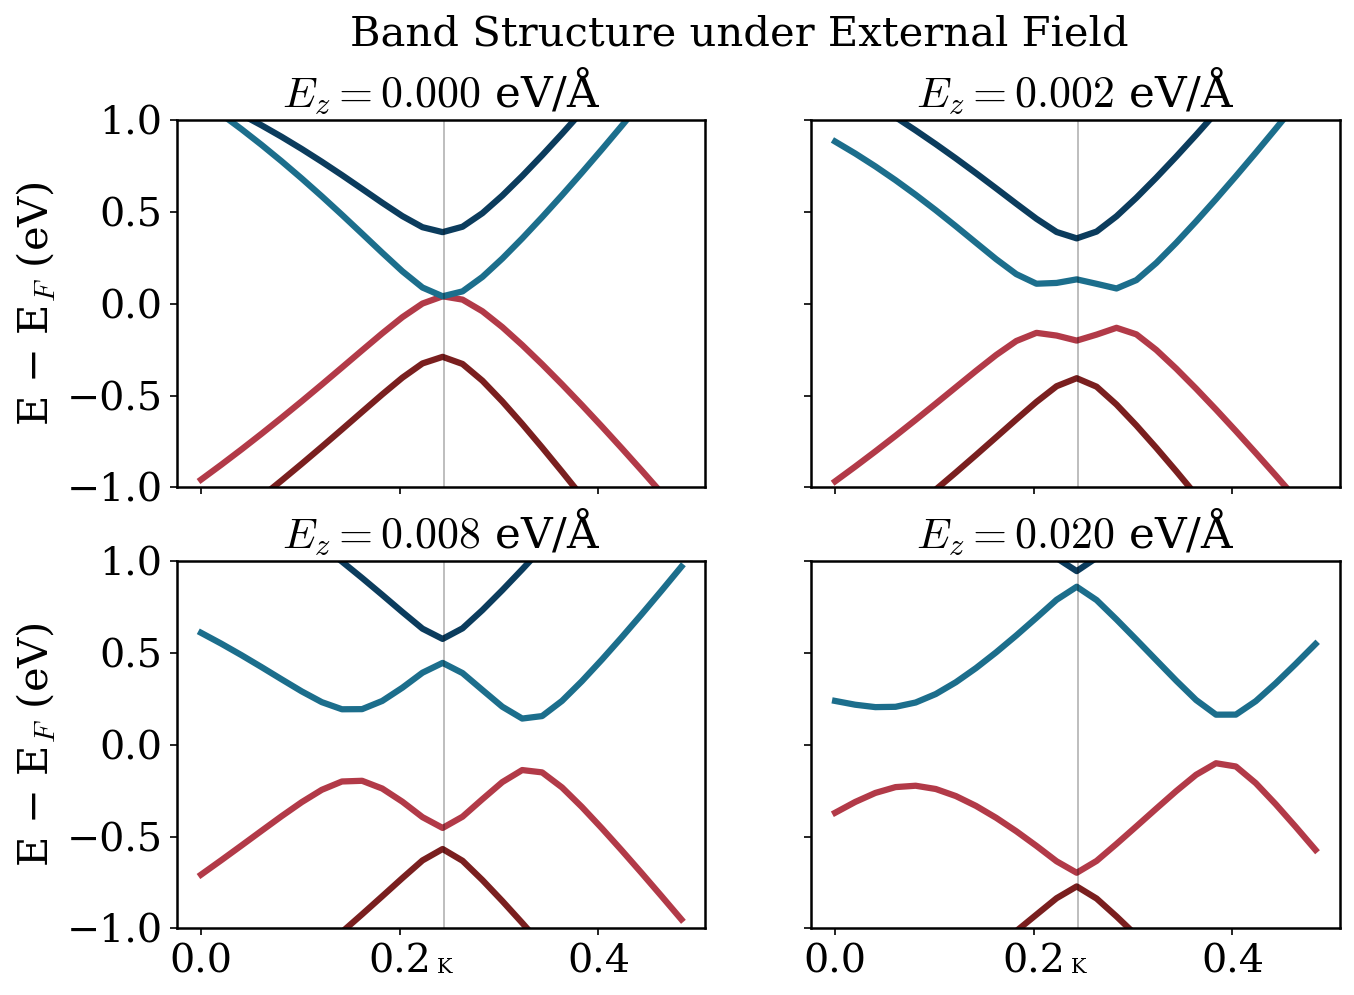

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
from common.mpl_style import set_mpl_style

# ----------------------------------
# Assumptions
# ----------------------------------
# fields_from_csv: array-like of (Ez, gpw_path)
# out_dir: directory containing the *_bands_KZOOM.npz files
# Each NPZ contains arrays: x, E
# ----------------------------------
set_mpl_style(linewidth=5, fontsize=20)
# Filter and clean fields (same logic as your GIF code)
fields_from_csv = fields_from_csv[fields_from_csv[:, 0] < 0.022]
fields_arr = np.array(fields_from_csv, dtype=object)

Ez_vals = np.round(fields_arr[:, 0].astype(float), 3)

# keep unique Ez (first occurrence)
_, unique_idx = np.unique(Ez_vals, return_index=True)
fields_arr = np.array(
    [(Ez_vals[i], fields_arr[i, 1]) for i in sorted(unique_idx)],
    dtype=object
)

# sort by field
idx = np.argsort(fields_arr[:, 0].astype(float))
fields_sorted = fields_arr[idx]

Ez_sorted = fields_sorted[:, 0].astype(float)

# ----------------------------------
# Choose target fields
# ----------------------------------
targets = [0.0, 0.002, 0.008, 0.02]
chosen = []

for t in targets:
    i = np.argmin(np.abs(Ez_sorted - t))
    chosen.append(fields_sorted[i])

# ----------------------------------
# Plot
# ----------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

#valence_colors = []      # dark → lighter blue
colors = ["#7A1F1F", "#B23A48",  "#1C6E8C", "#0B3C5D",]  # dark → lighter red

for ax, (_Ez, _gpw) in zip(axes, chosen):
    _Ez = float(_Ez)
    npz_path = os.path.join(
        out_dir,
        f"ab_gate_plane_A{_Ez:.3f}_bands_KZOOM.npz"
    )

    if not os.path.exists(npz_path):
        ax.set_title(f"Ez = {_Ez:.3f} eV/Å\n(MISSING)")
        continue

    data = np.load(npz_path)
    x = data["x"]
    E = data["E"]

    pi_bands_index, pi_bands_vals = [], []
    for n in range(E.shape[1]):
        if np.any((E[:, n] > -1) & (E[:, n] < 1)):
            pi_bands_index.append(n)
            pi_bands_vals.append(E[5, n])

    ordered_indexes = np.argsort(pi_bands_vals)
    ordered_ns = np.array(pi_bands_index)[ordered_indexes]
   # print(ordered_ns)
    #print('for ', _Ez)
    for n in range(E.shape[1]):
        if np.any((E[:, n] > -1) & (E[:, n] < 1)):
            #print('plotting  ', E[:])

            ax.plot(x, E[:, n], lw=3, color=colors[np.argmax(ordered_ns==n)])

    ax.set_title(f"$E_z = {_Ez:.3f}$ eV/Å")

# ----------------------------------
# Common formatting
# ----------------------------------

for ax in axes:
    ax.set_ylim(-1.0, 1.0)
    ax.grid(False)

K_pos = 0.245

i = 0
for ax in axes:
    ax.axvline(K_pos, color="k", lw=0.8, alpha=0.3)  # optional, but useful
    if i >= 2:
        ax.text(
            K_pos,
            -0.08,
            "K",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top"
        )
    i += 1


#axes[2].set_xlabel("k (cumulative path)")
#axes[3].set_xlabel("k (cumulative path)")
axes[0].set_ylabel("E − E$_F$ (eV)")
axes[2].set_ylabel("E − E$_F$ (eV)")

fig.suptitle(
    "Band Structure under External Field",
    fontsize=20
)

plt.savefig('../data/different_fields.png')
plt.savefig('../data/different_fields.pdf')
#plt.tight_layout(rect=[0, 0, 1, 0.94])
#plt.show()
